# KDUQ corpus: neutron elastic

The KDUQ corpus is a reconstruction of the experimental data used in the Koning-Delaroche global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Neutron differential elastic scattering cross sections, stored in b/sr against CM scattering angle.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/kduq_neutron_elastic.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('kduq', 'neutron_elastic')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

608 rows, 237 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,kduq,neutron_elastic,neutron,24,12,24Mg,3.400,None,30463008,,4
1,kduq,neutron_elastic,neutron,24,12,24Mg,6.100,None,21490002,,4
2,kduq,neutron_elastic,neutron,24,12,24Mg,9.760,None,21773002,,4
3,kduq,neutron_elastic,neutron,24,12,24Mg,14.830,None,21773010,,4
4,kduq,neutron_elastic,neutron,0,12,natMg,1.969,None,11493004,,4
5,kduq,neutron_elastic,neutron,0,12,natMg,2.958,None,11493004,,4
6,kduq,neutron_elastic,neutron,0,12,natMg,3.948,None,11493004,,4
7,kduq,neutron_elastic,neutron,0,12,natMg,4.958,None,11493004,,4
8,kduq,neutron_elastic,neutron,0,12,natMg,5.440,None,10105006,,4
9,kduq,neutron_elastic,neutron,0,12,natMg,6.440,None,10105006,,4


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('kduq', 'neutron_elastic')
print(result.summary())

kduq/neutron_elastic
  spec rows              608
  ... marked absent      2
  ... resolved           585 / 606 (96.5%)
  measurements           579
  data points            14888
  EXFOR entries          125
  unresolved by category
    x4i3-parse-failure       13
    subentry-withdrawn       5
    uncertainty-unresolved   3
    absent-from-exfor        2
  serialized             579 measurements, 14888 points
  dropped during cleaning
    10817007: one or more data points carry no uncertainty
    10867003: one or more data points carry no uncertainty
    11215049: one or more data points carry no uncertainty
    11877006: one or more data points carry no uncertainty
    11877007: one or more data points carry no uncertainty
    11877009: one or more data points carry no uncertainty


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

natCu   155.000           [absent-from-exfor] the supplement marks this row as absent from EXFOR
natPb   155.000           [absent-from-exfor] the supplement marks this row as absent from EXFOR
natMg     1.969 11493004  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
natMg     2.958 11493004  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
natMg     3.948 11493004  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
natMg     4.958 11493004  [x4i3-parse-failure] parse failed: 'NoneType' object is not subscriptable
59Co     23.000 12962004  [x4i3-parse-failure] parse failed: Error while parsing 12962004: Attempted to extract error column POL-BM-ERR with incompatible unitsno-dim for data column DATA-CM with units barns/ster
208Pb    23.000 12962006  [x4i3-parse-failure] parse failed: Error while parsing 12962006: Attempted to extract error column POL-BM-ERR with incompatible unitsno-dim for data column DATA-CM with

## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Every parsed data set is plotted, one figure per target, grouped by incident energy and
offset for legibility. Outliers here are found by eye: a mistranscribed point shows up
as a single datum an order of magnitude away from its neighbours; a badly normalised
data set shows up as a whole curve offset from others at the same energy. Nothing is
sampled or truncated -- the count of plotted data sets is checked against the number
written below, because a data set that is never drawn is one whose outliers are never
found.

/mnt/ufs18/rs/reactiontheoryinitiative/nucleon_nucleus_data/src/nn_corpora/plotting.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, y_size), squeeze=False)


plotted all 579 data sets


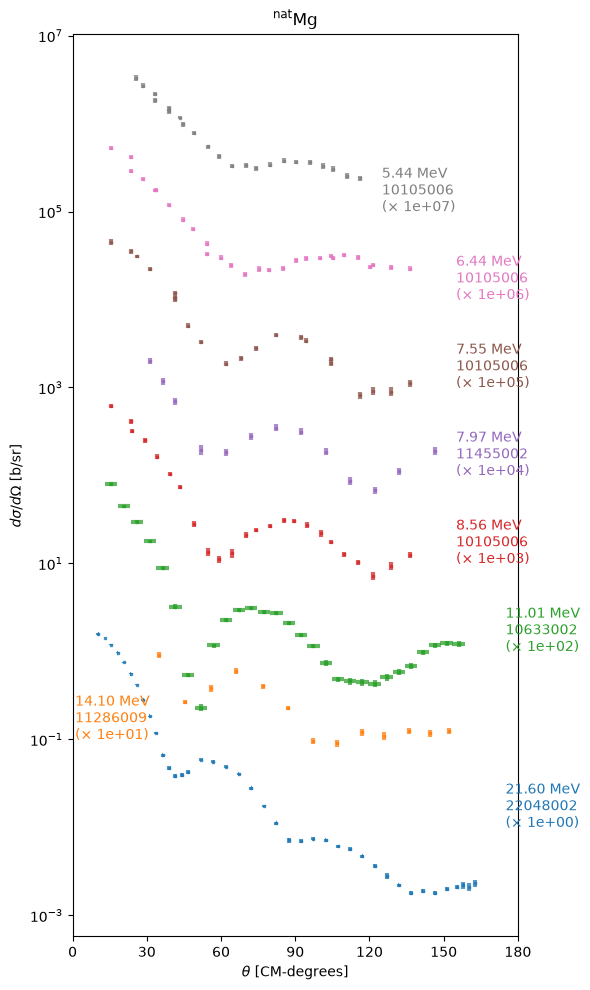

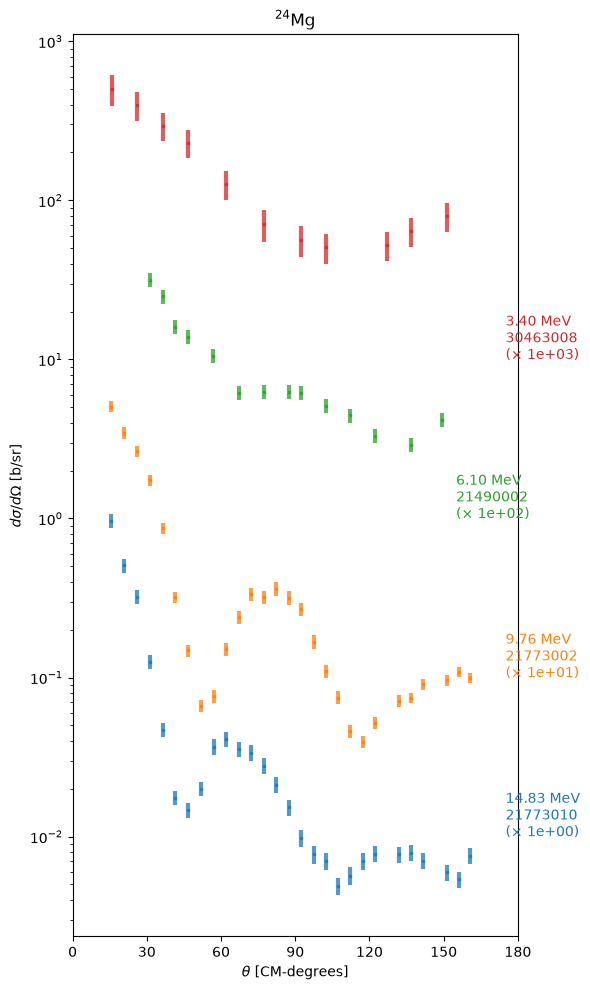

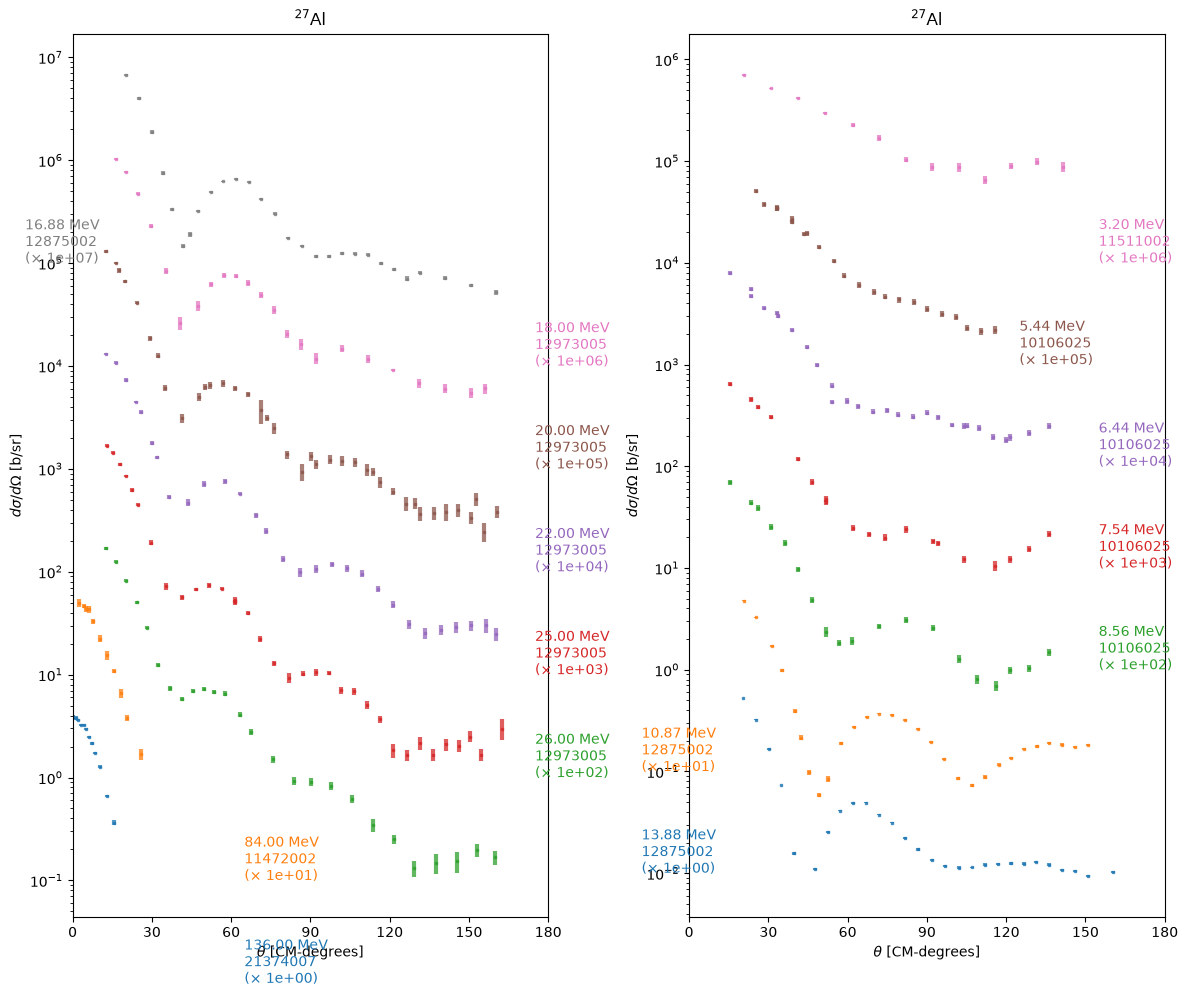

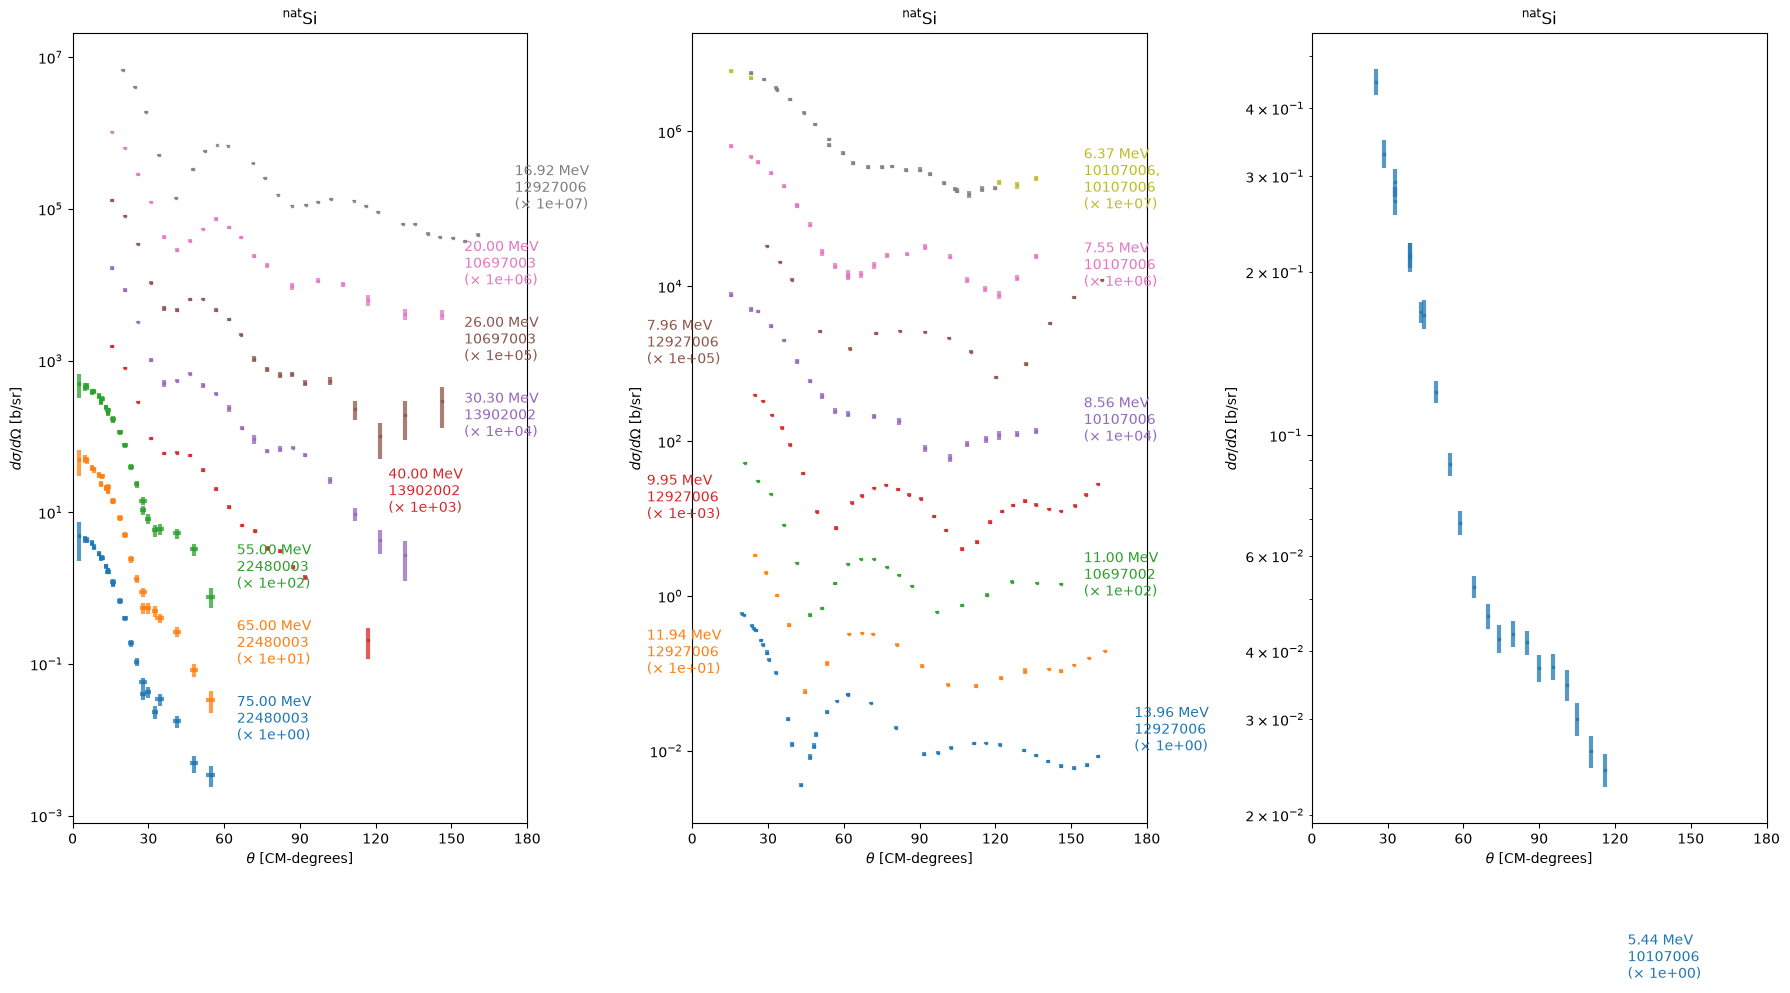

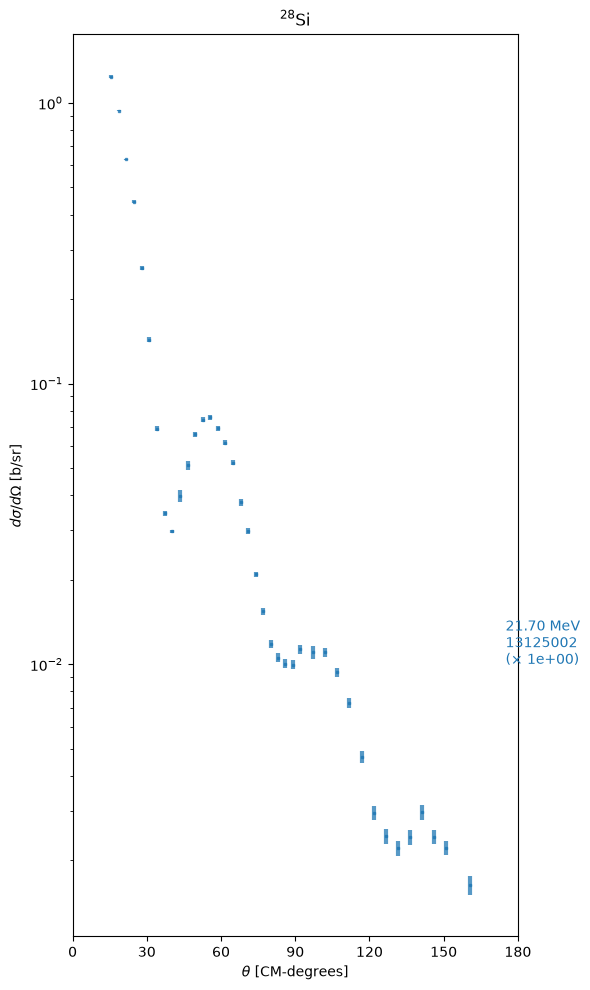

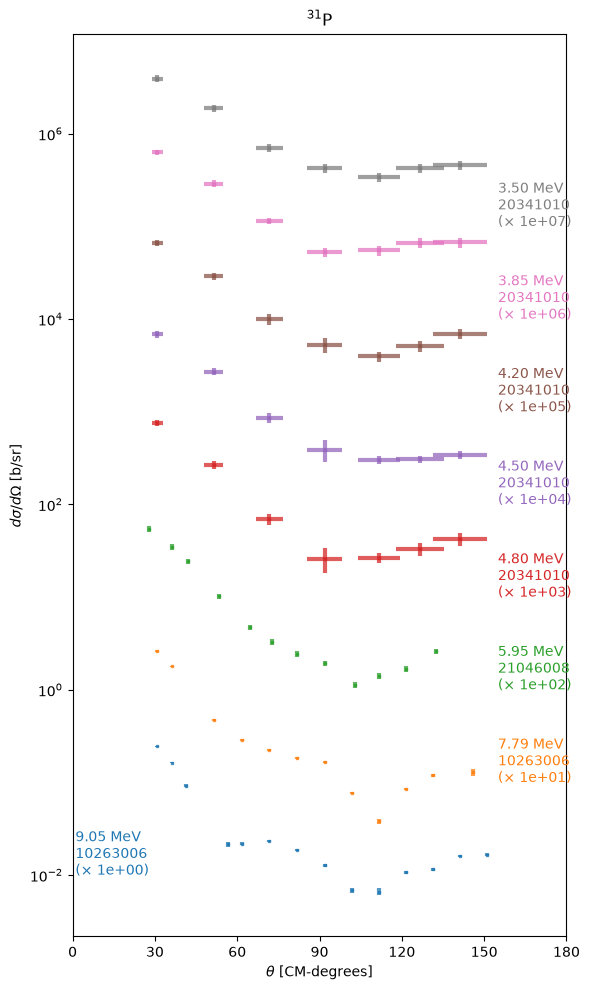

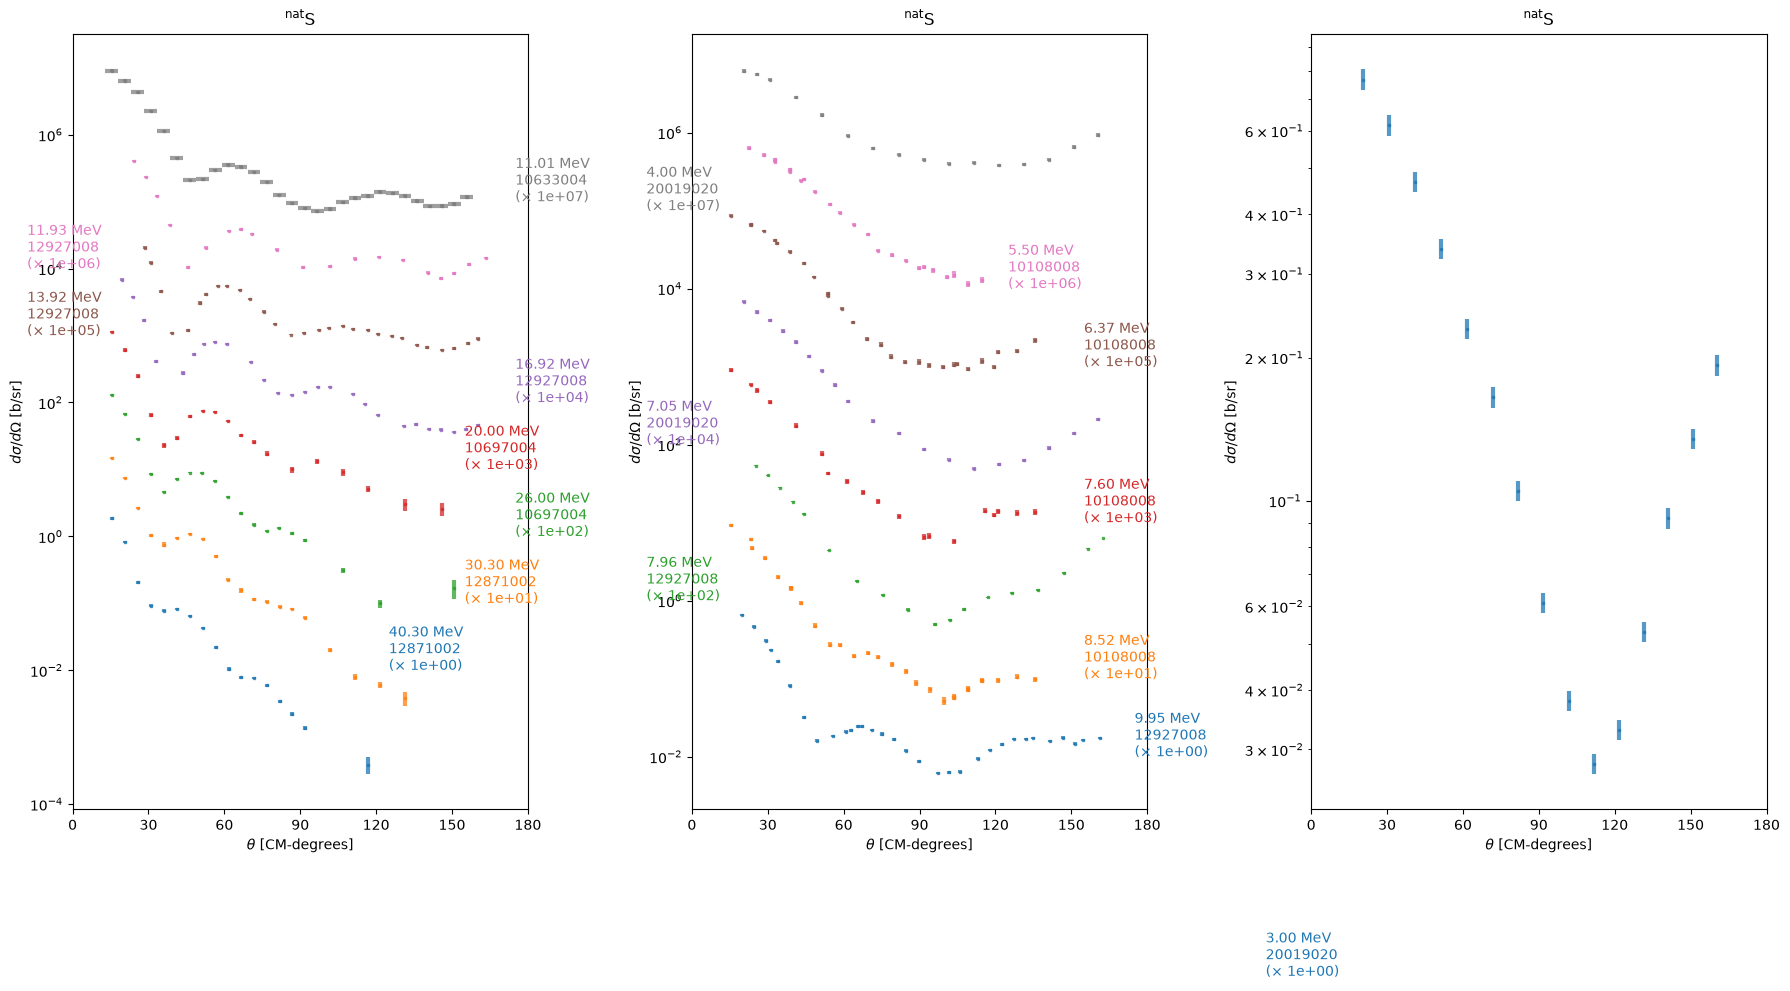

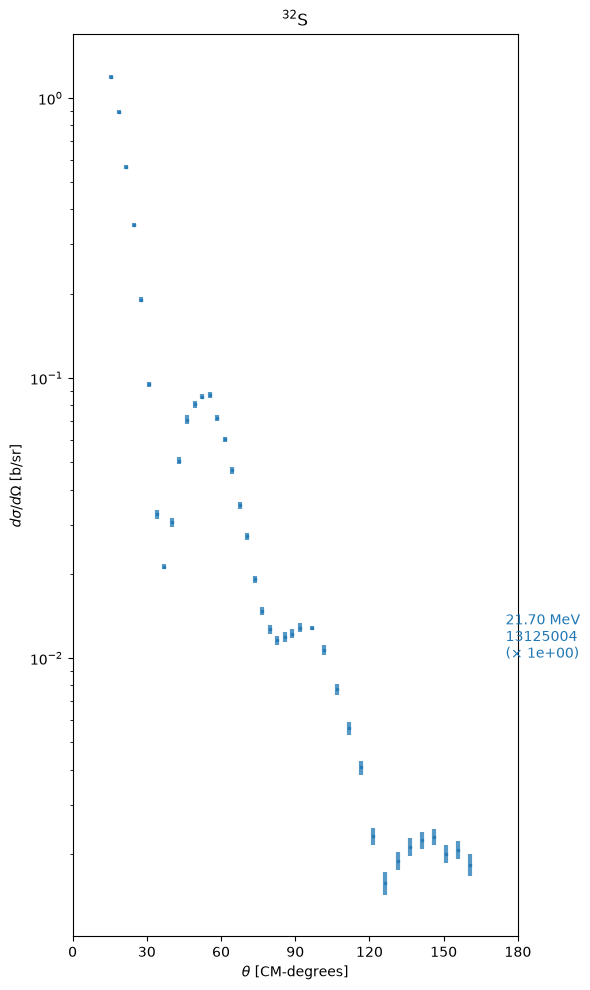

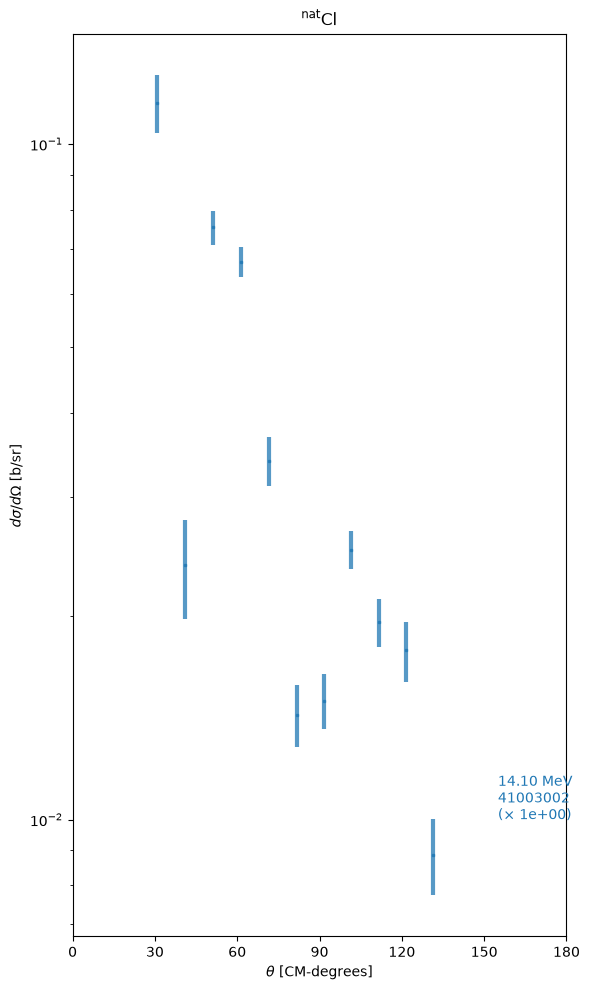

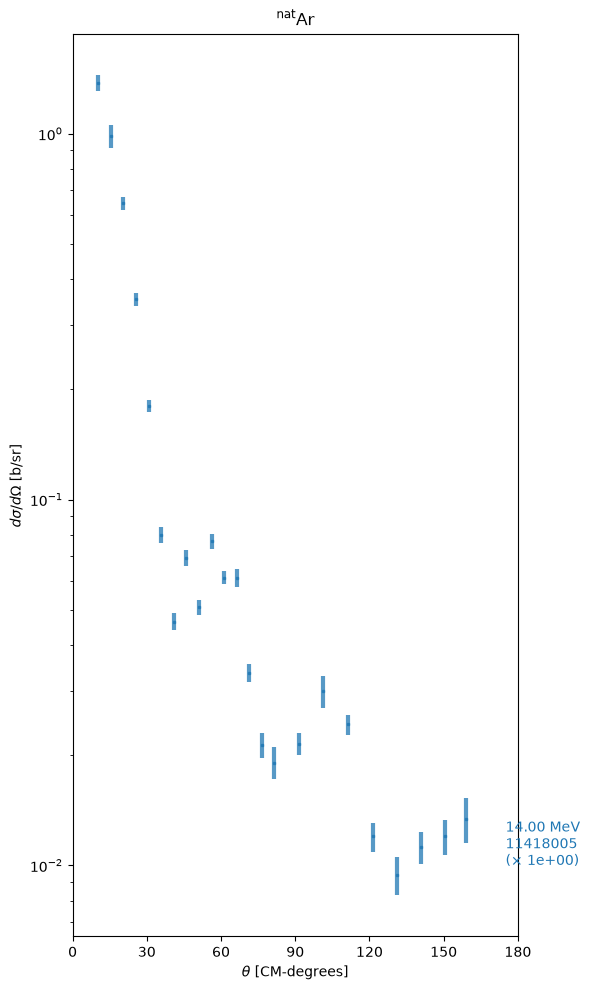

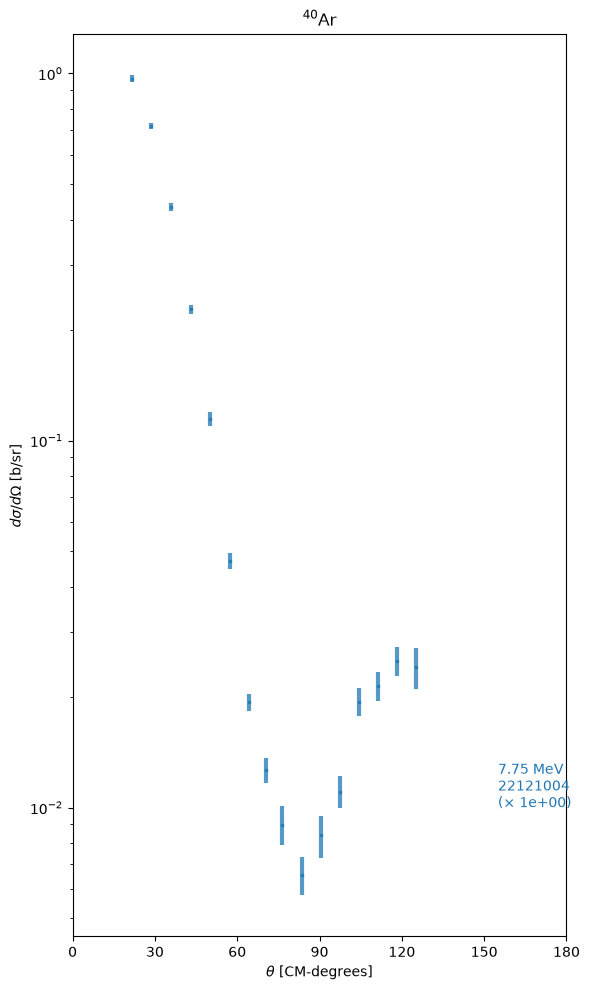

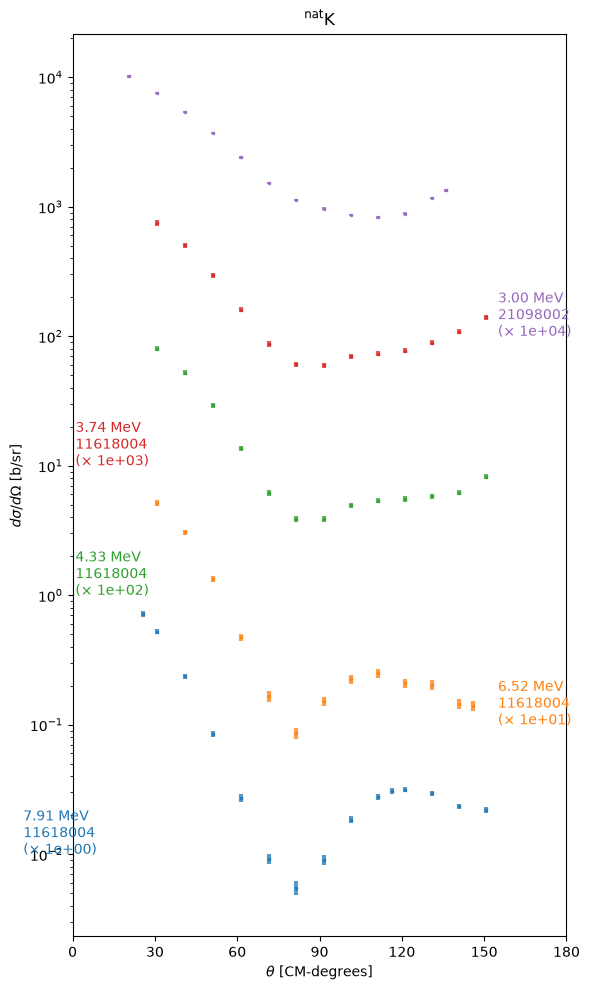

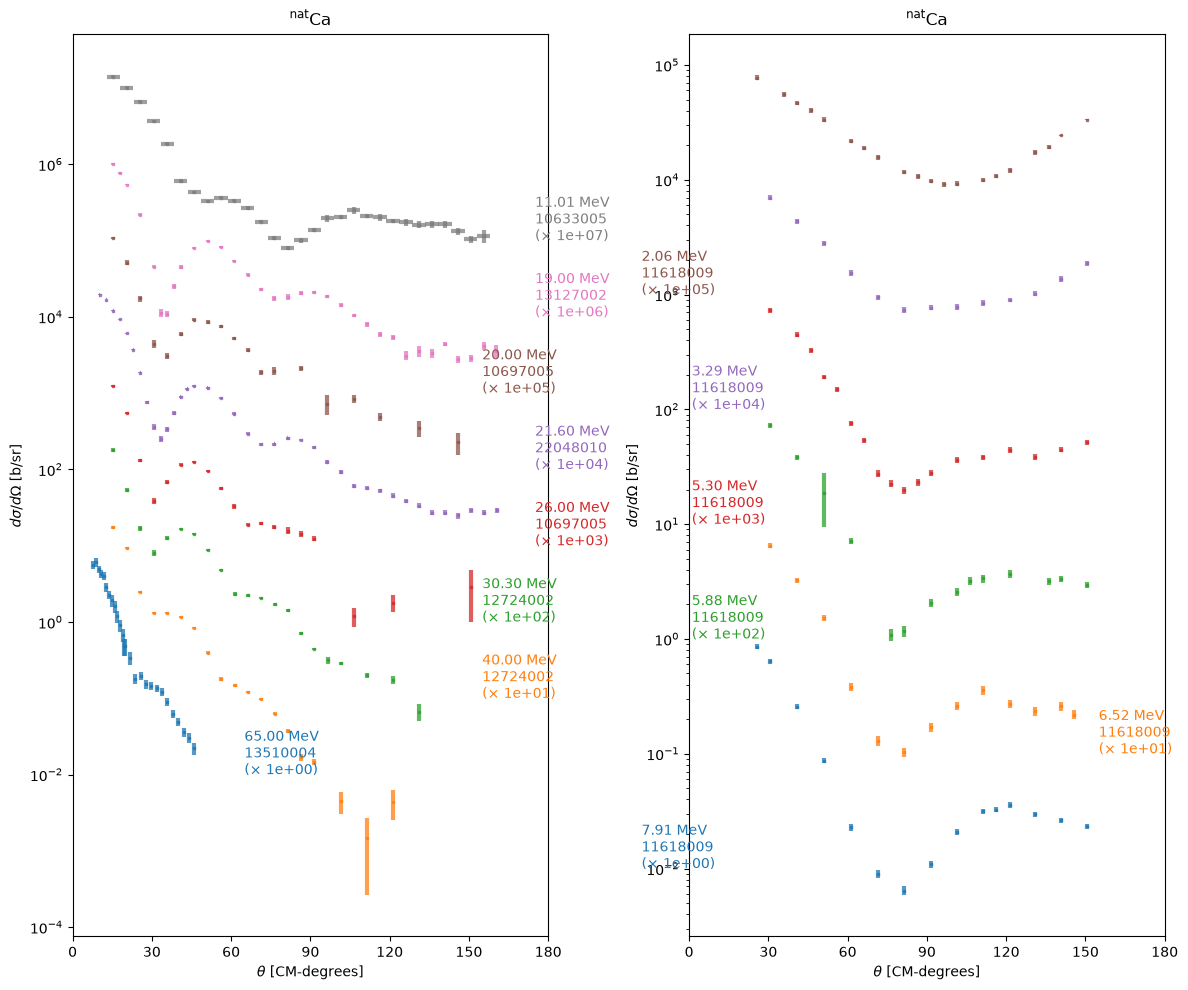

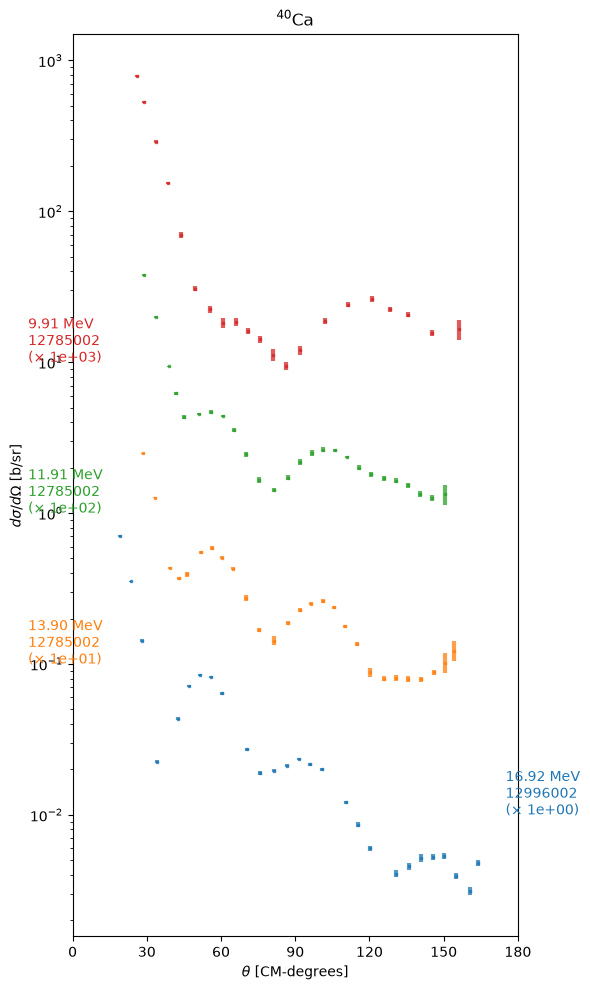

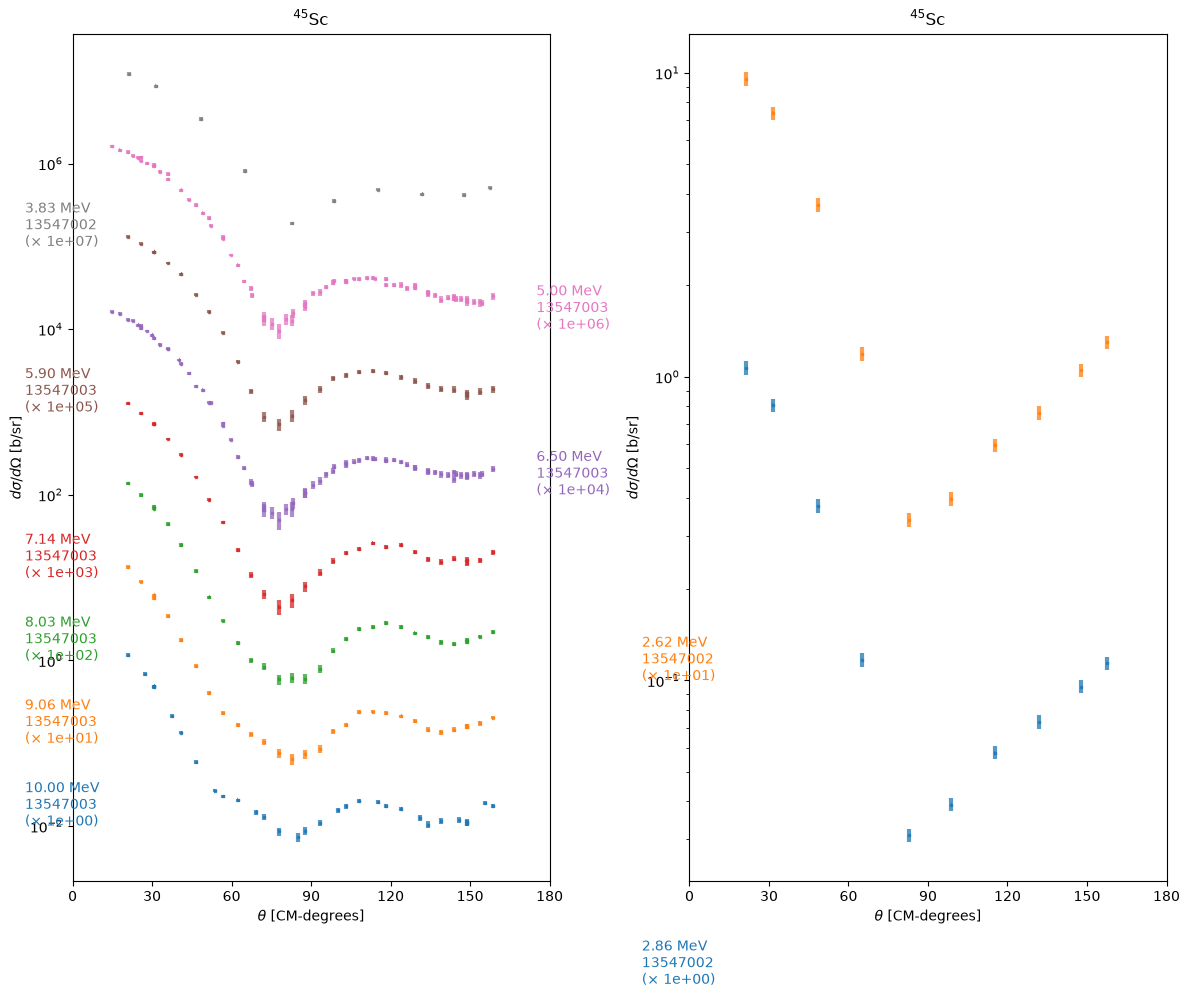

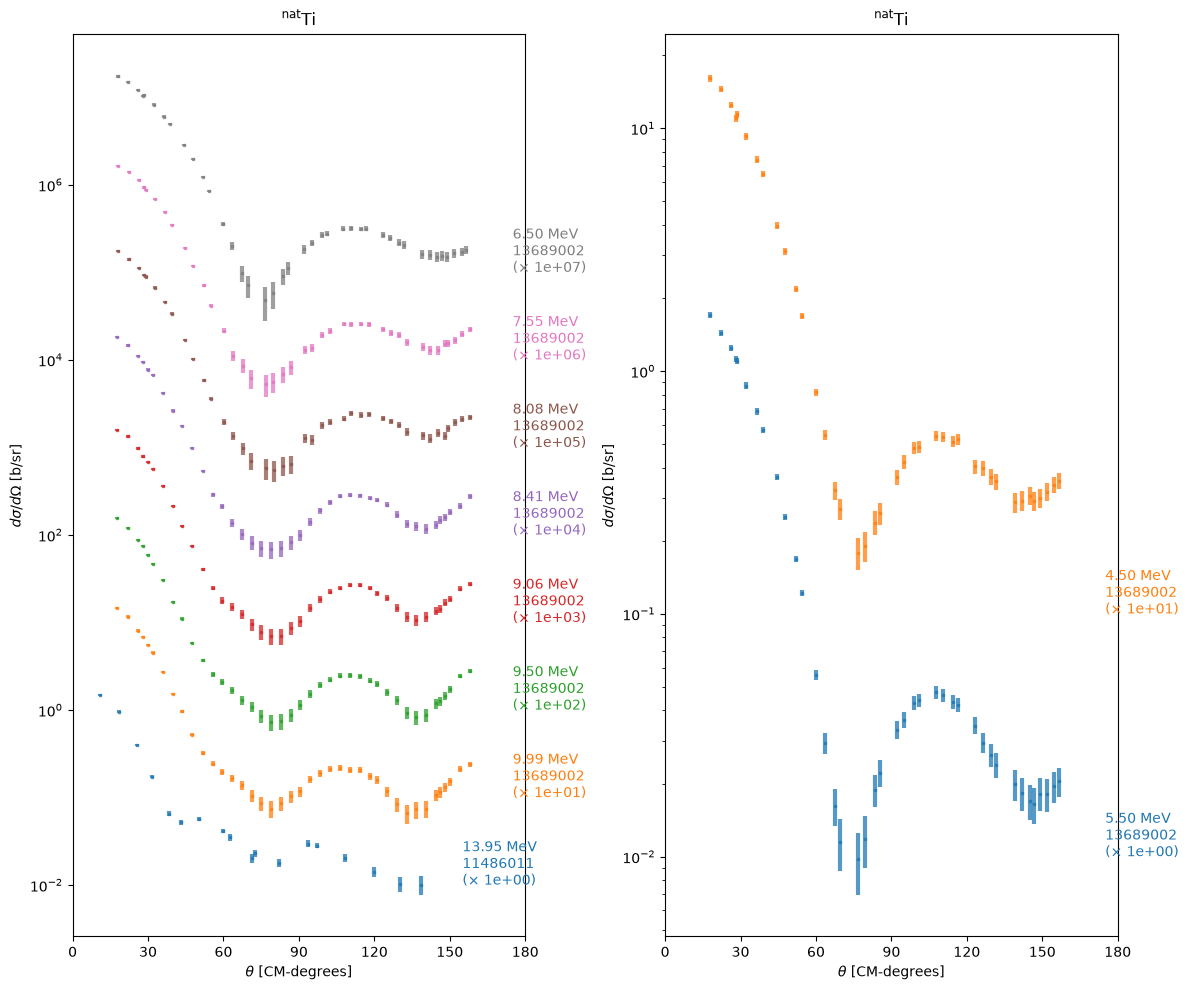

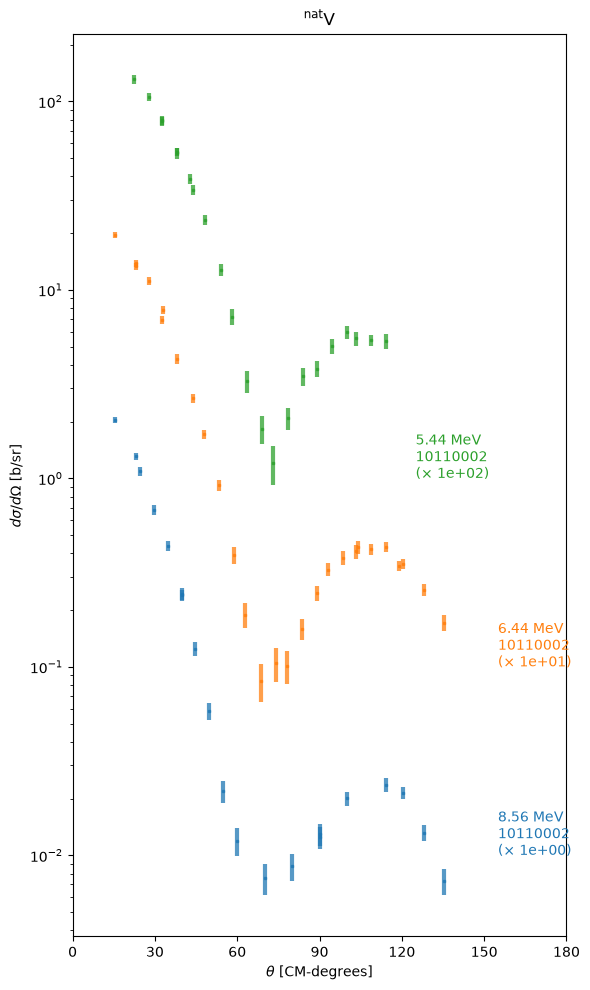

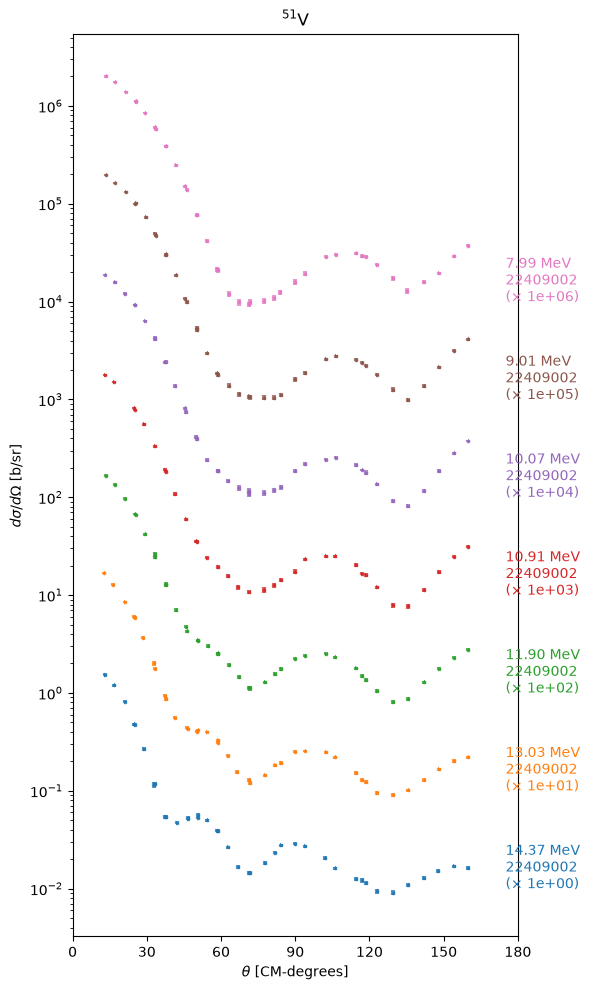

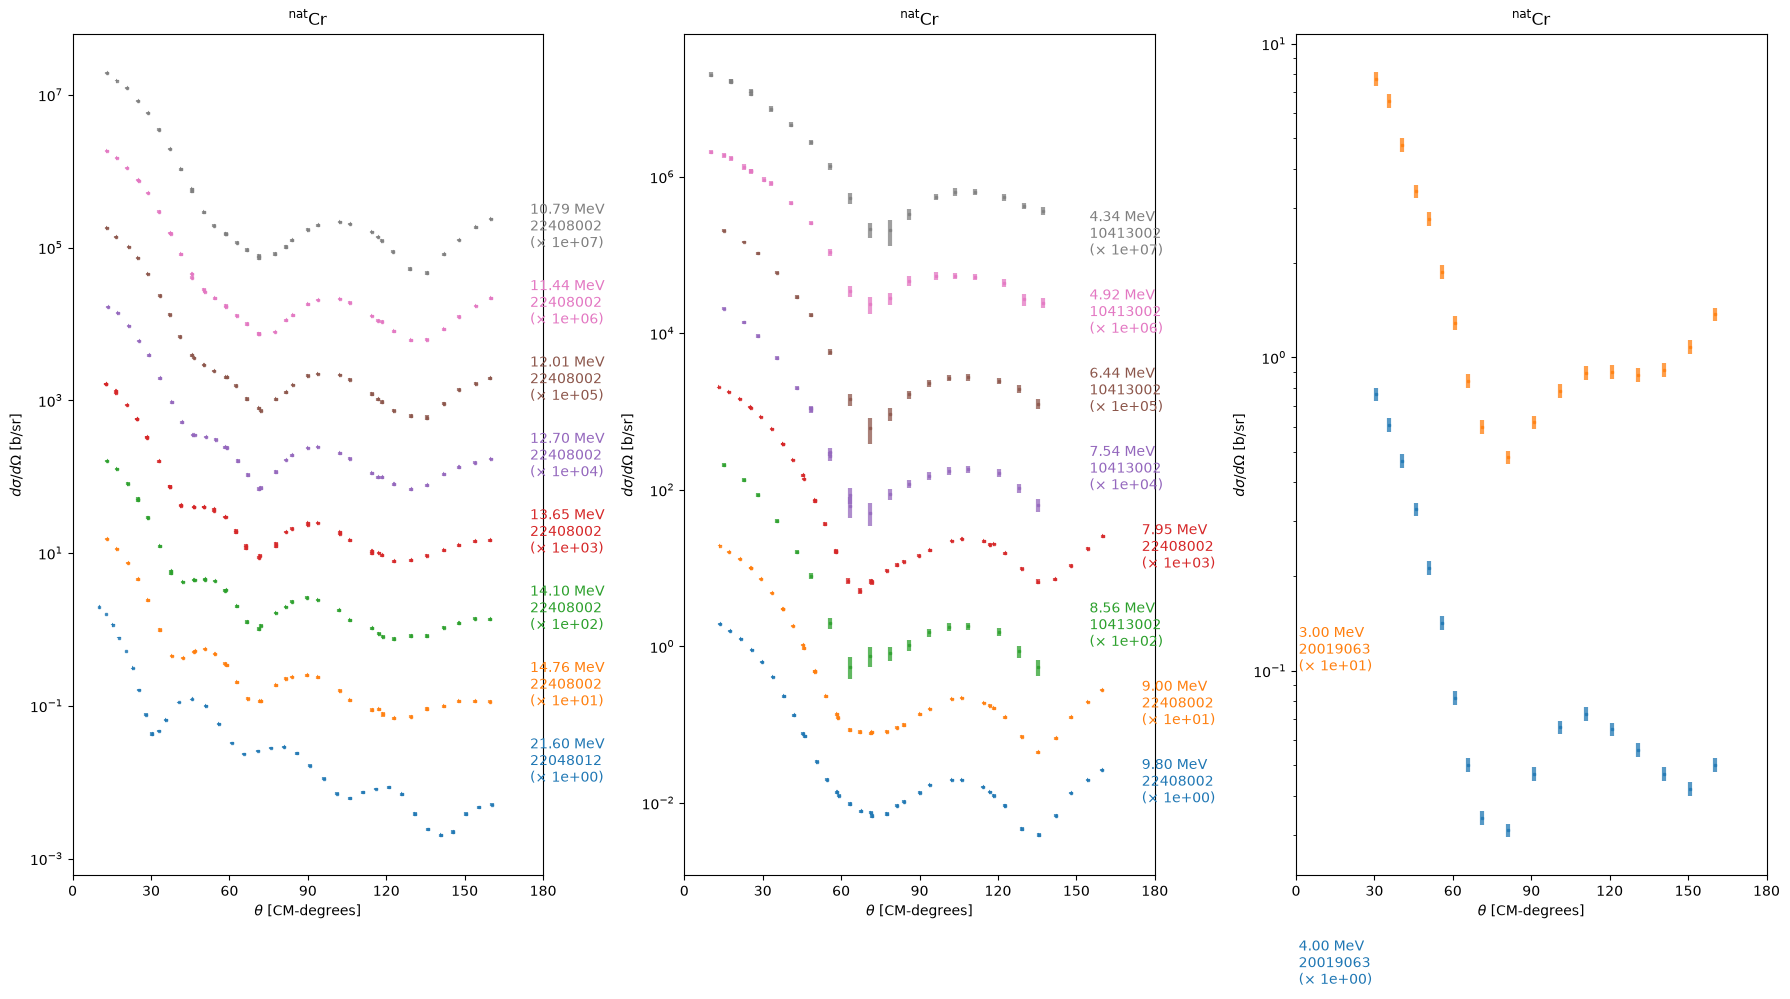

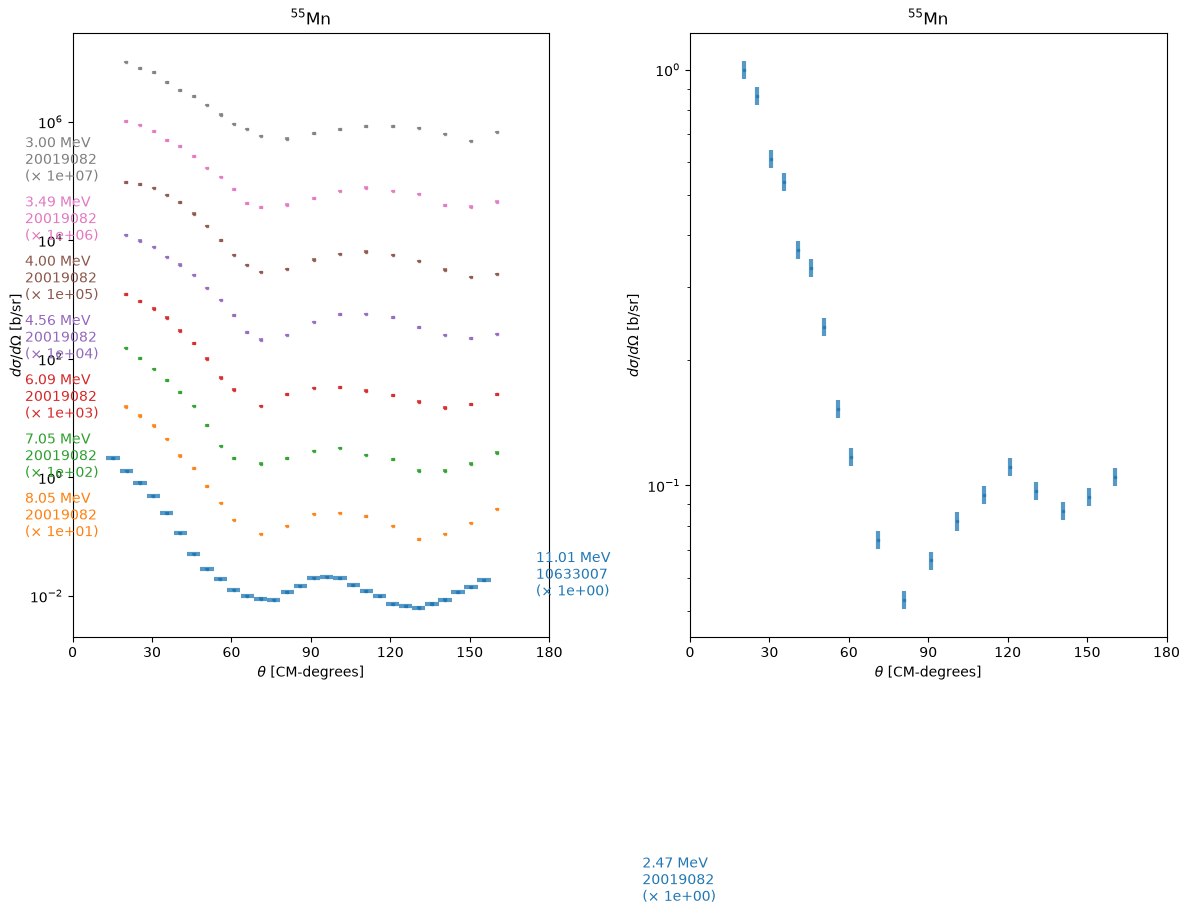

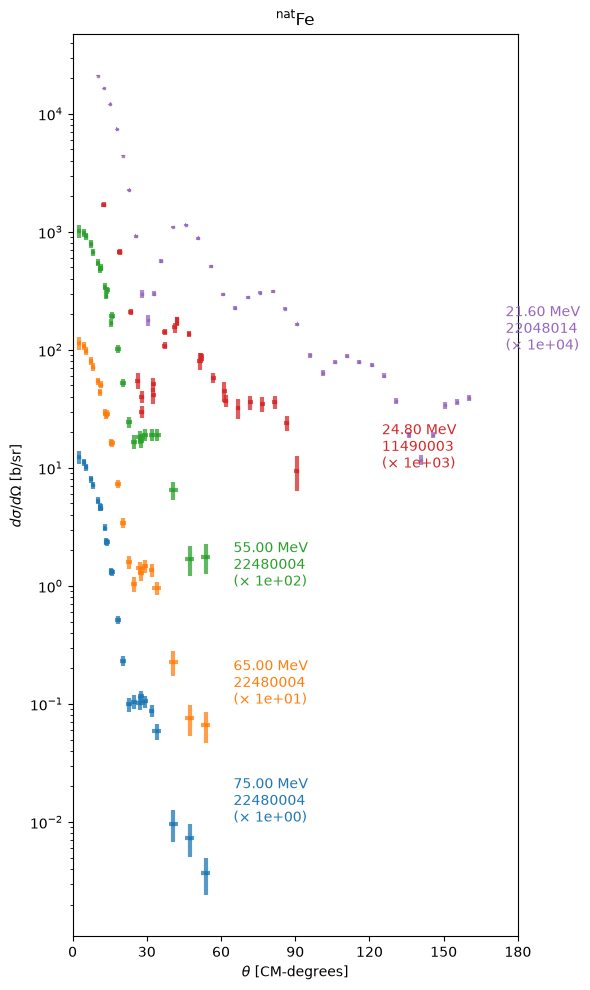

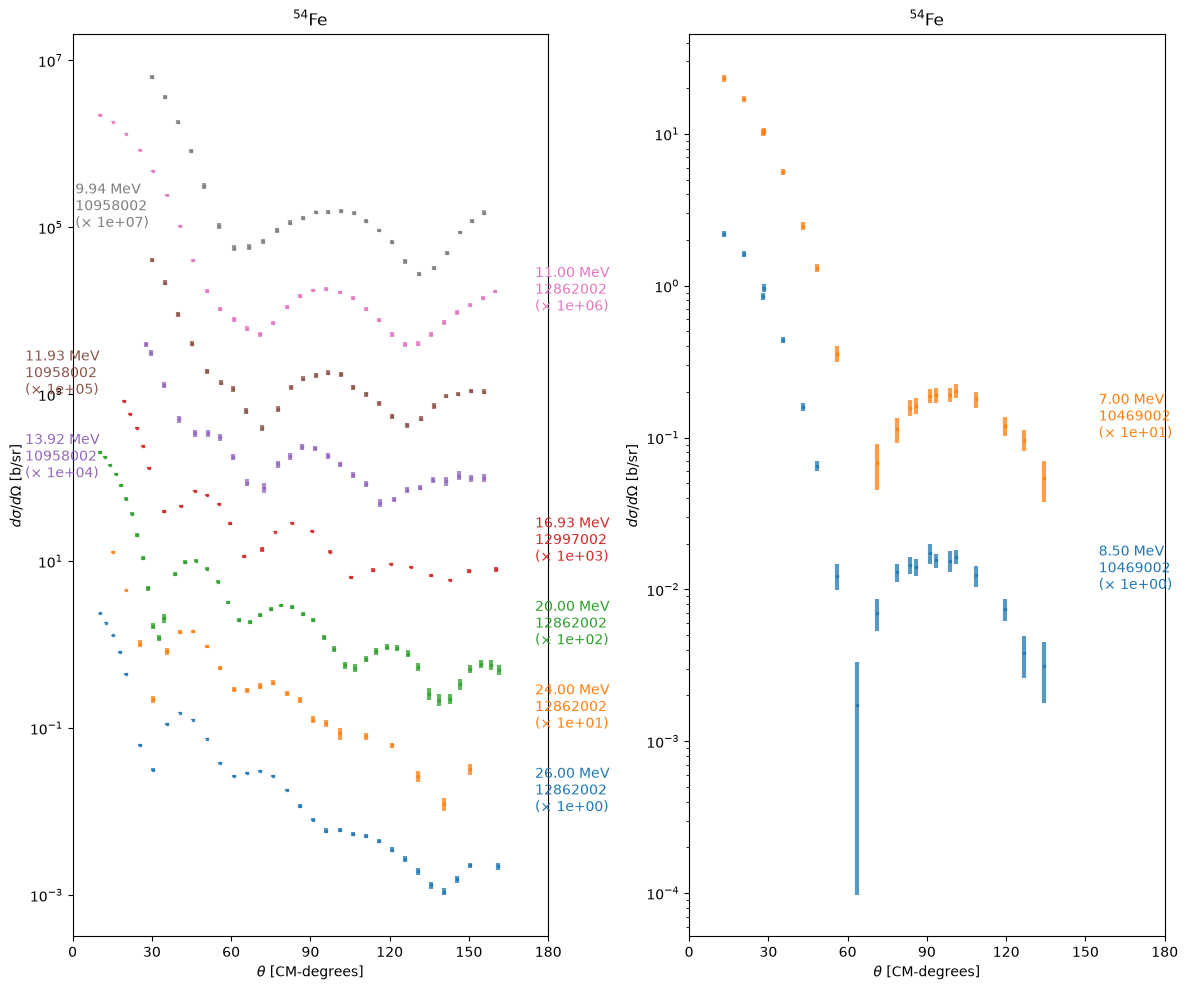

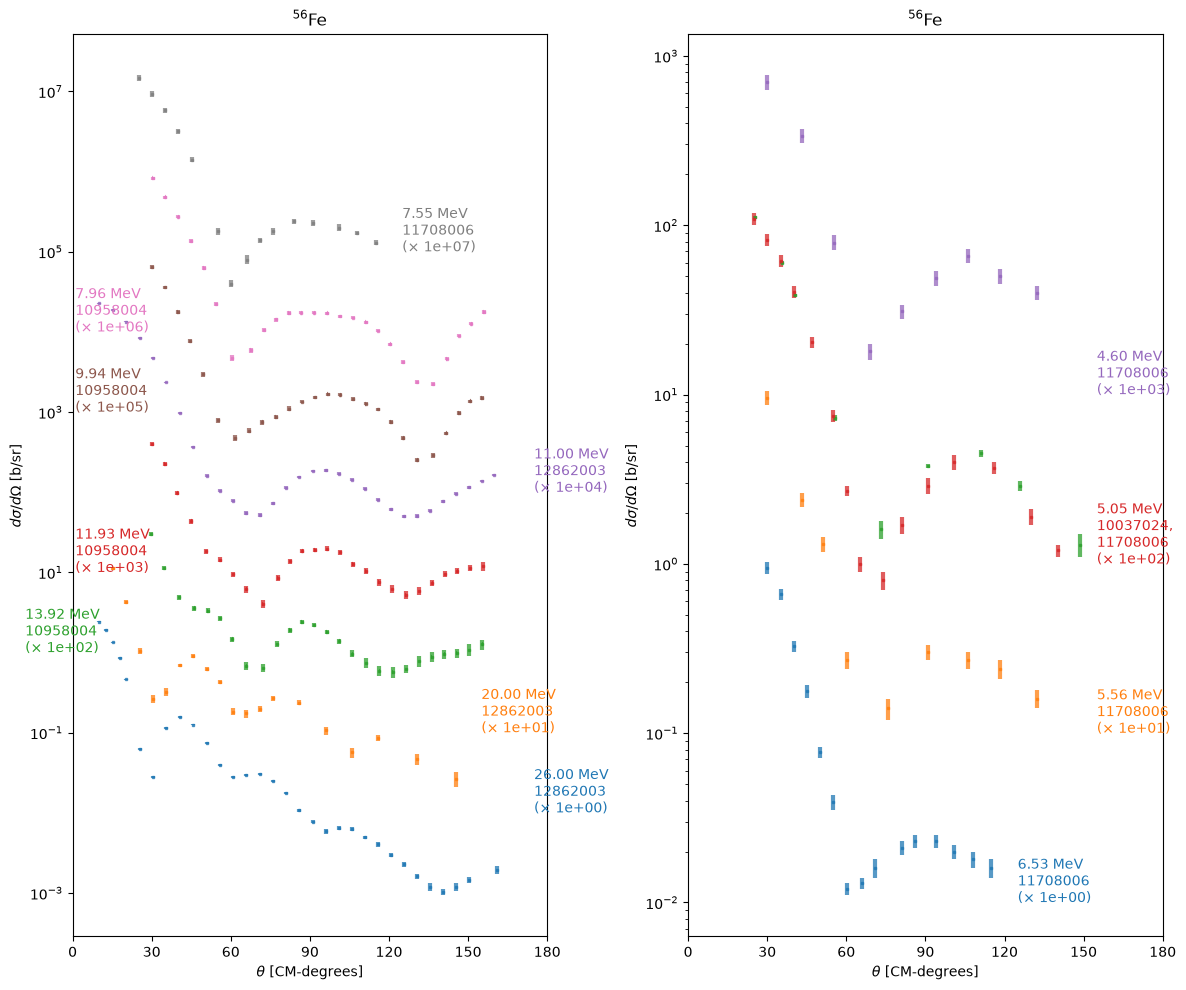

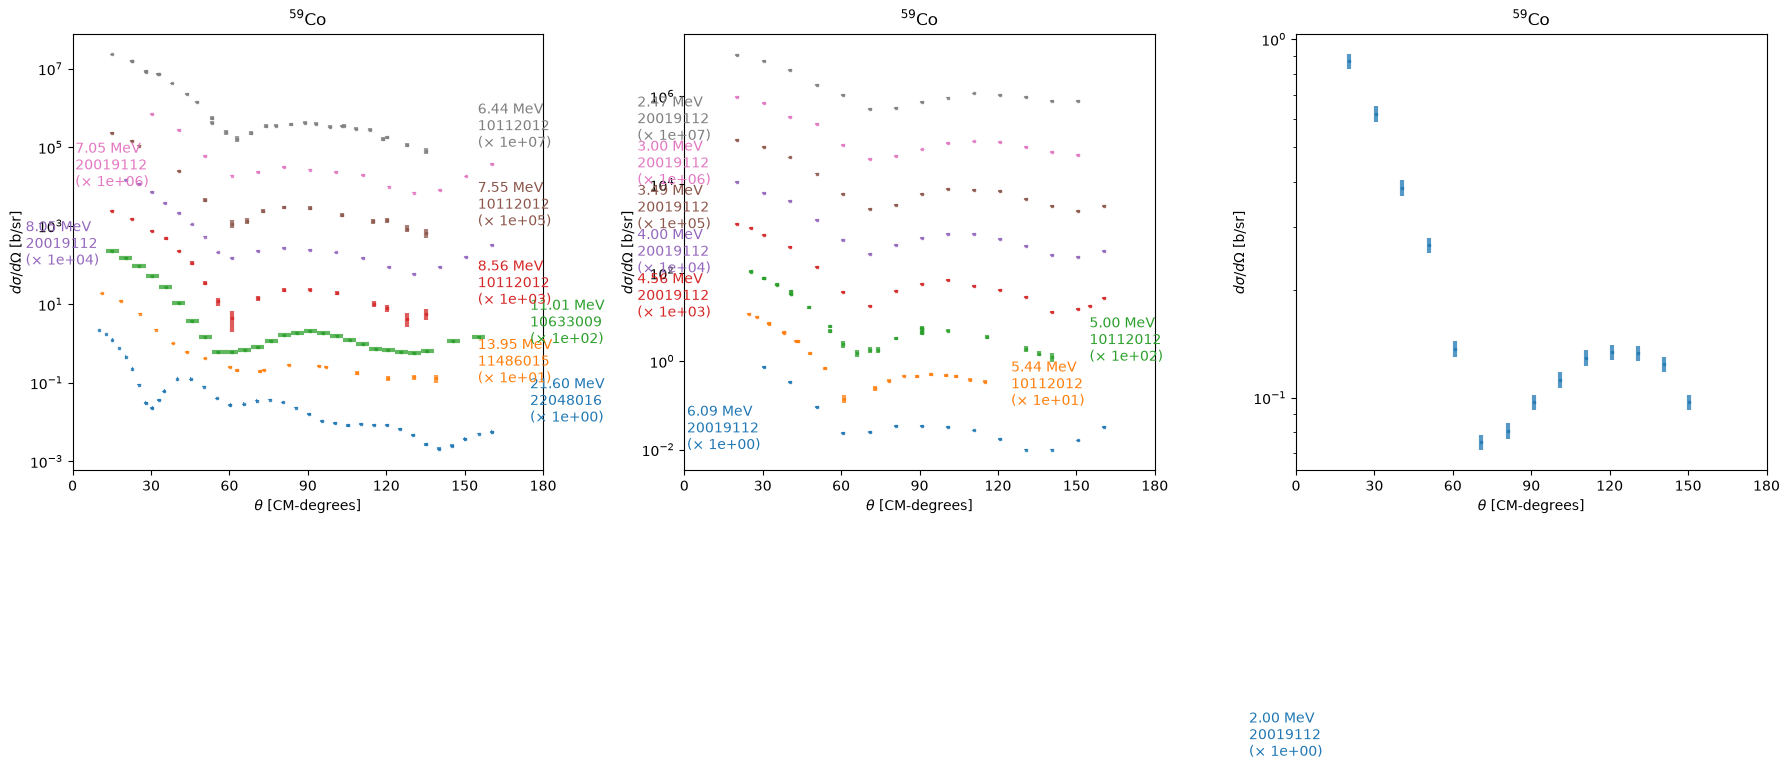

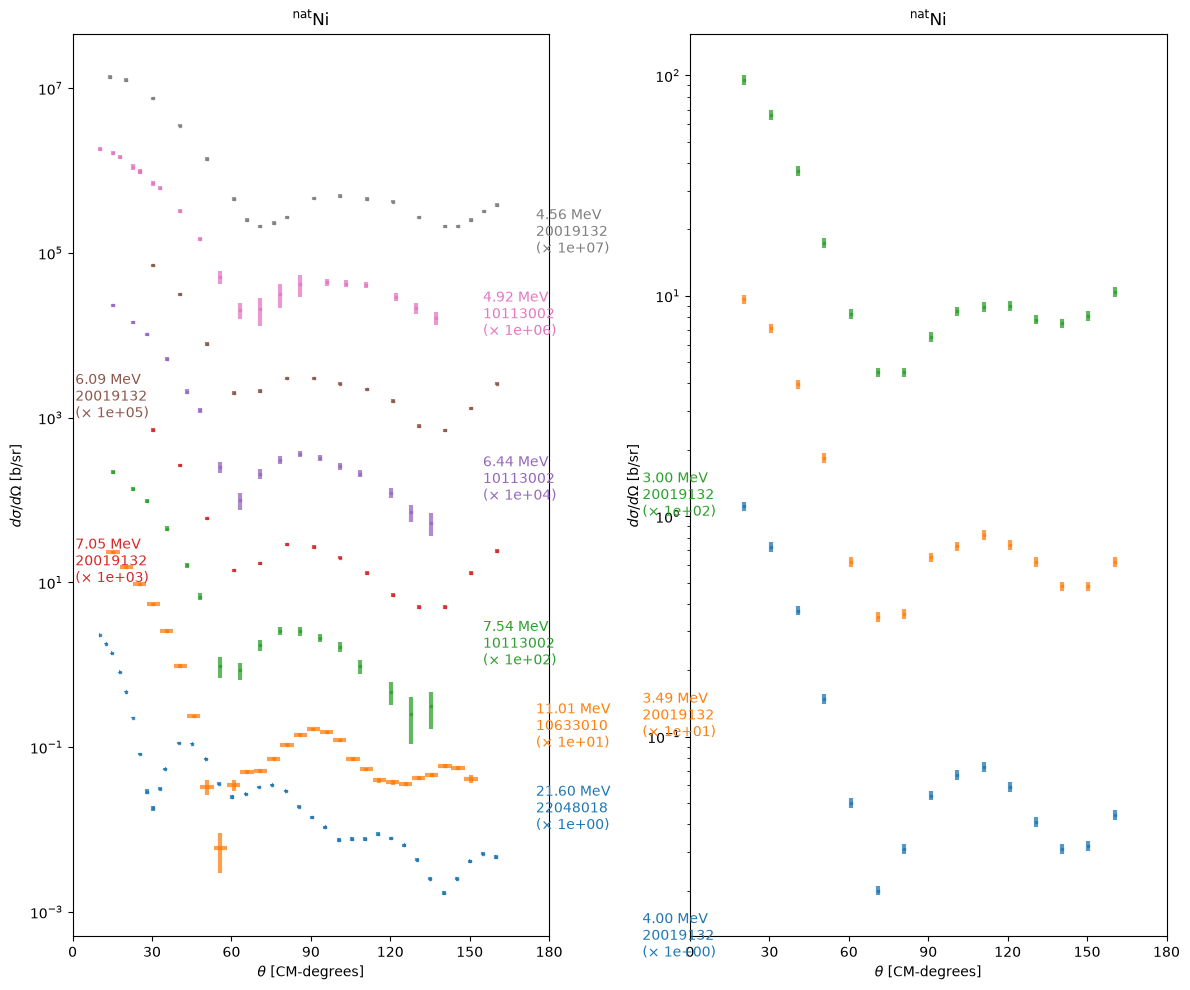

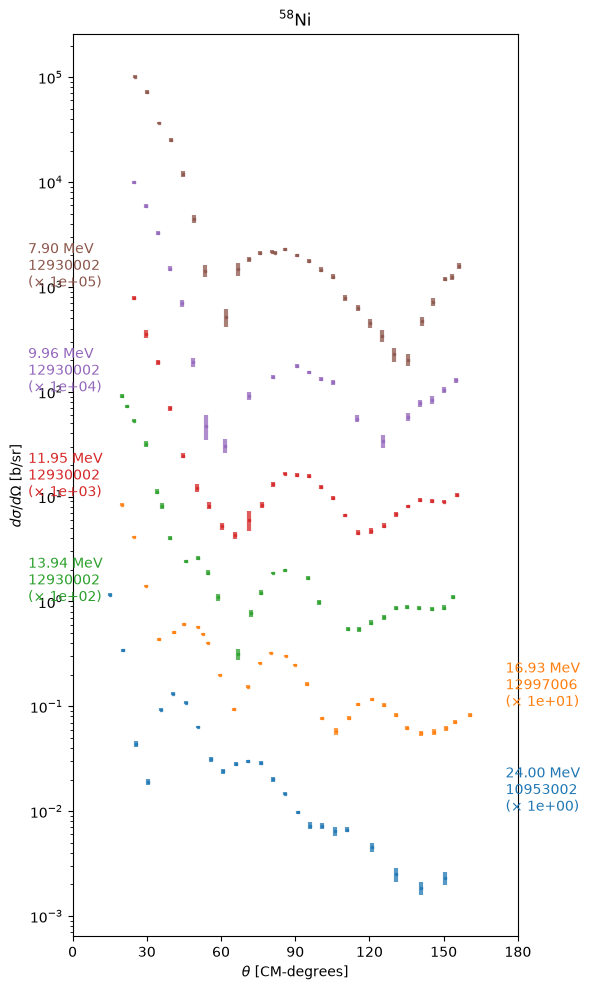

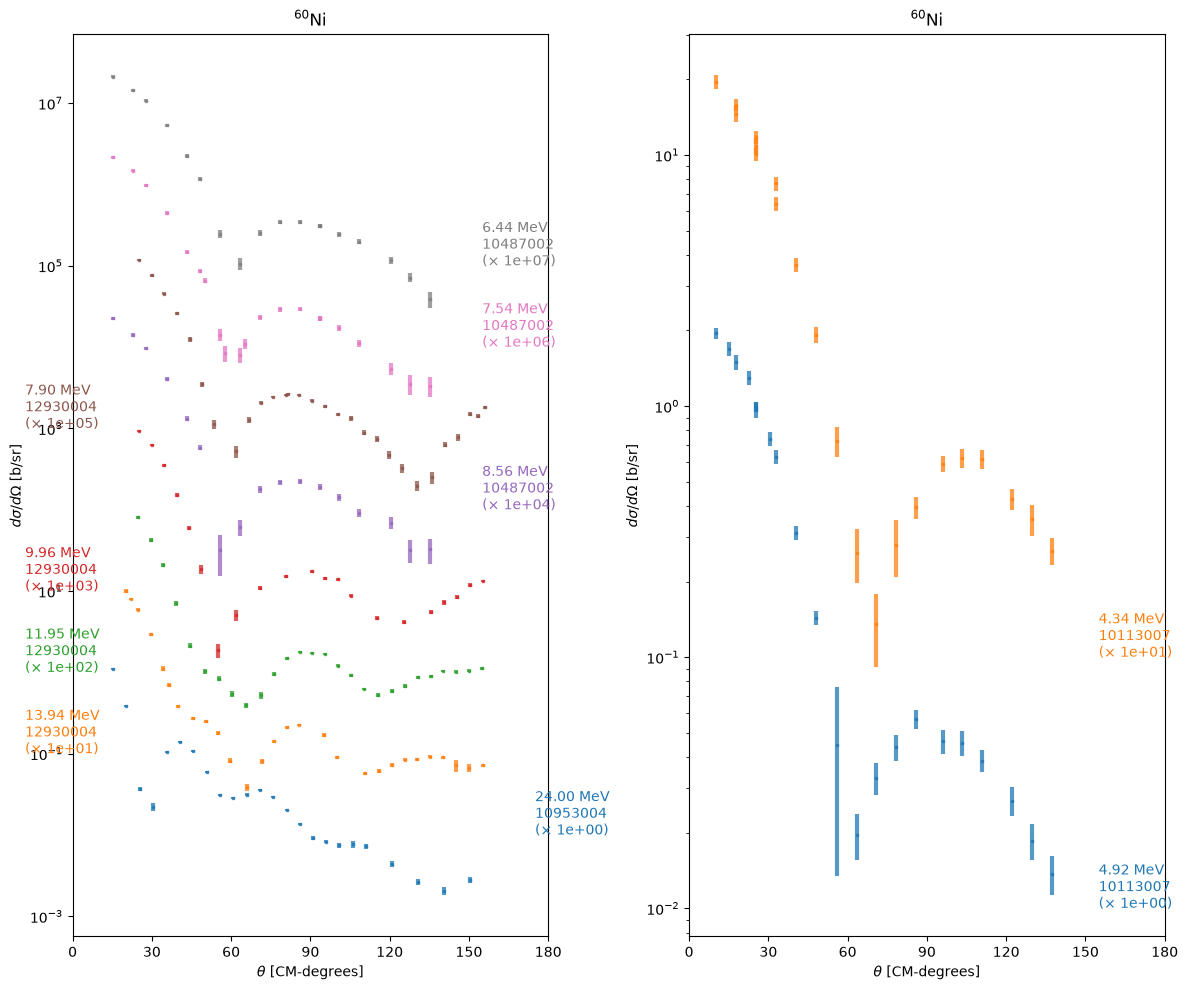

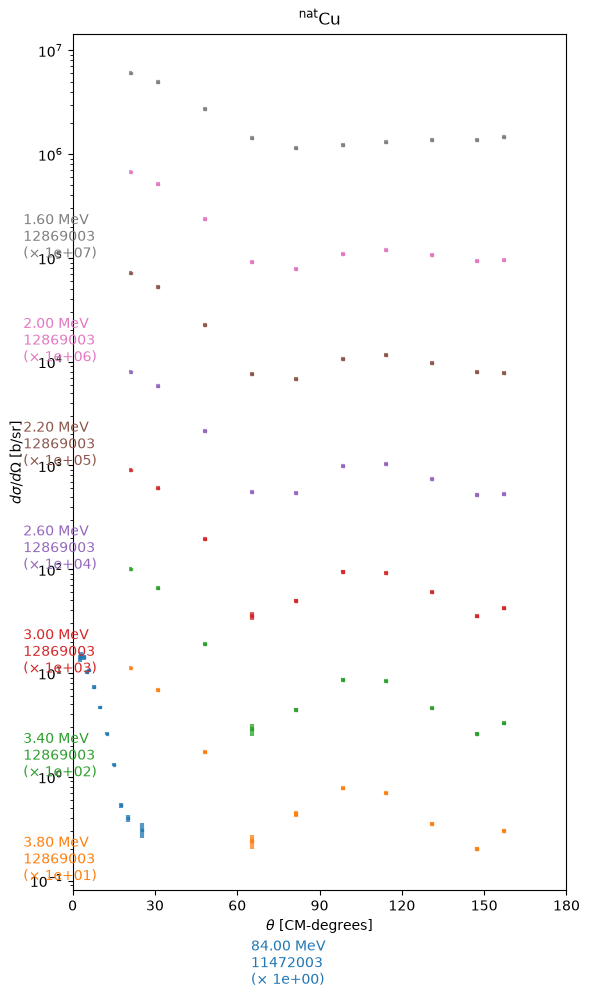

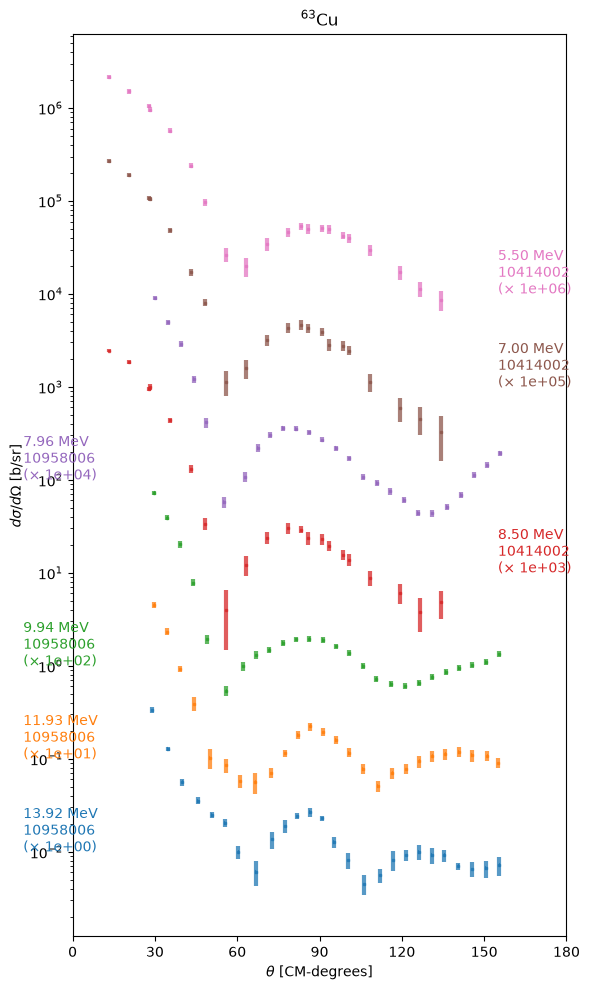

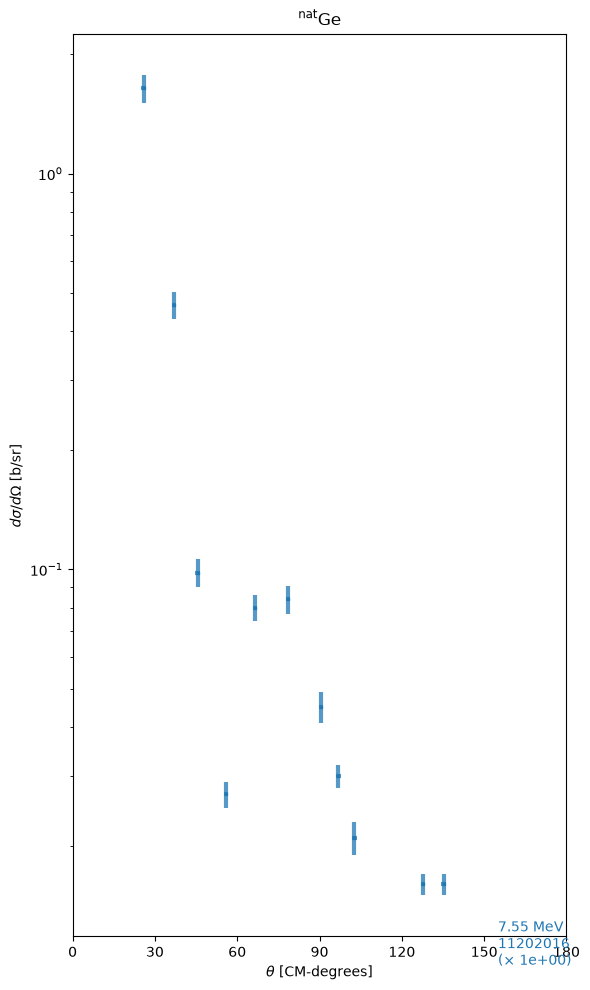

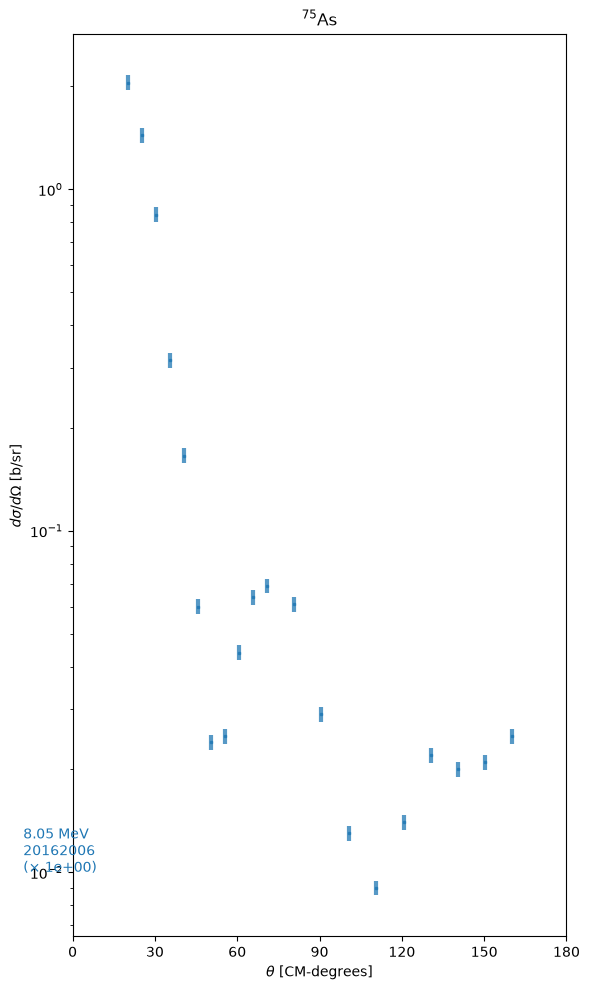

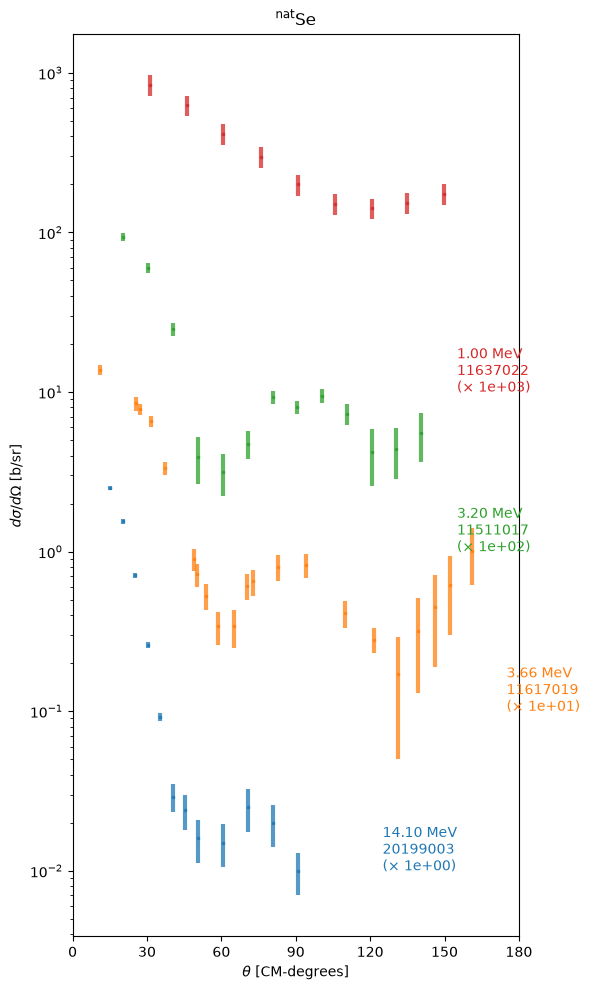

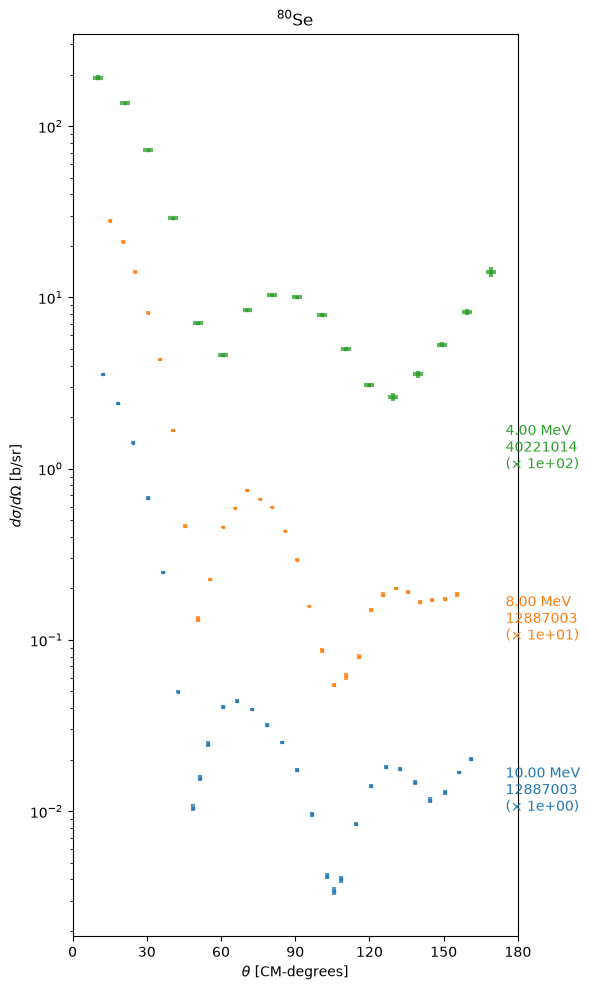

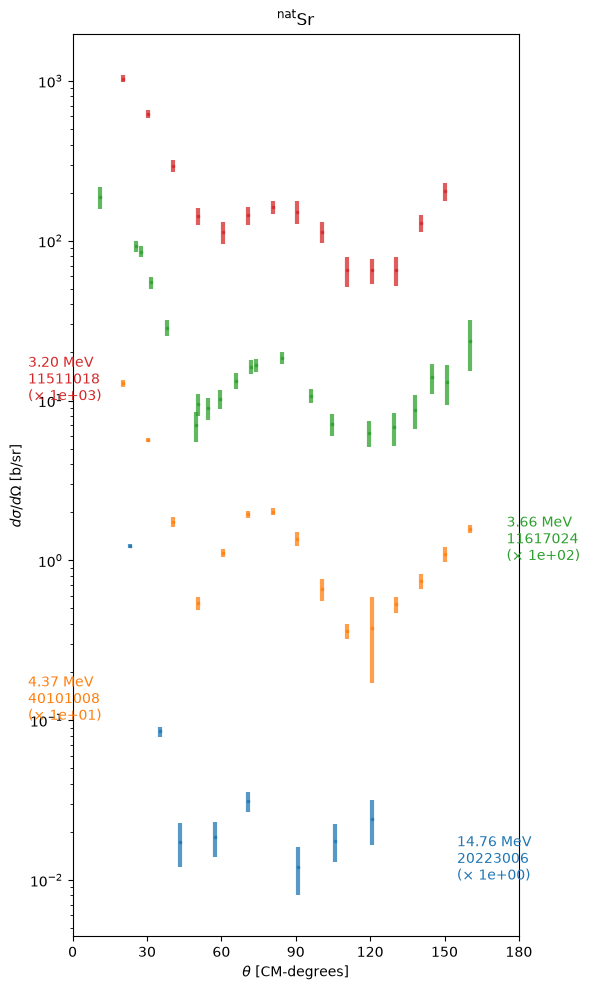

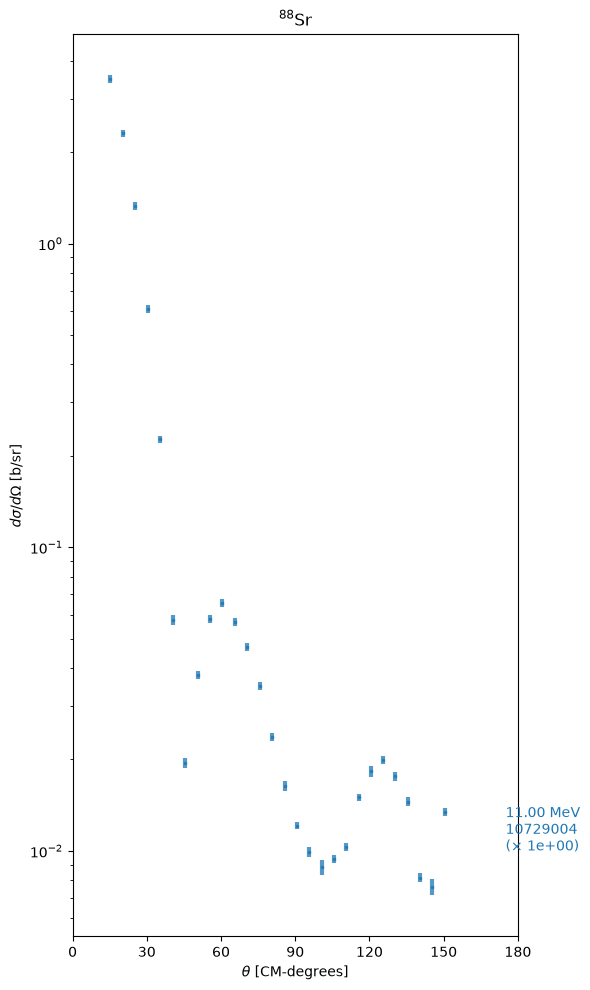

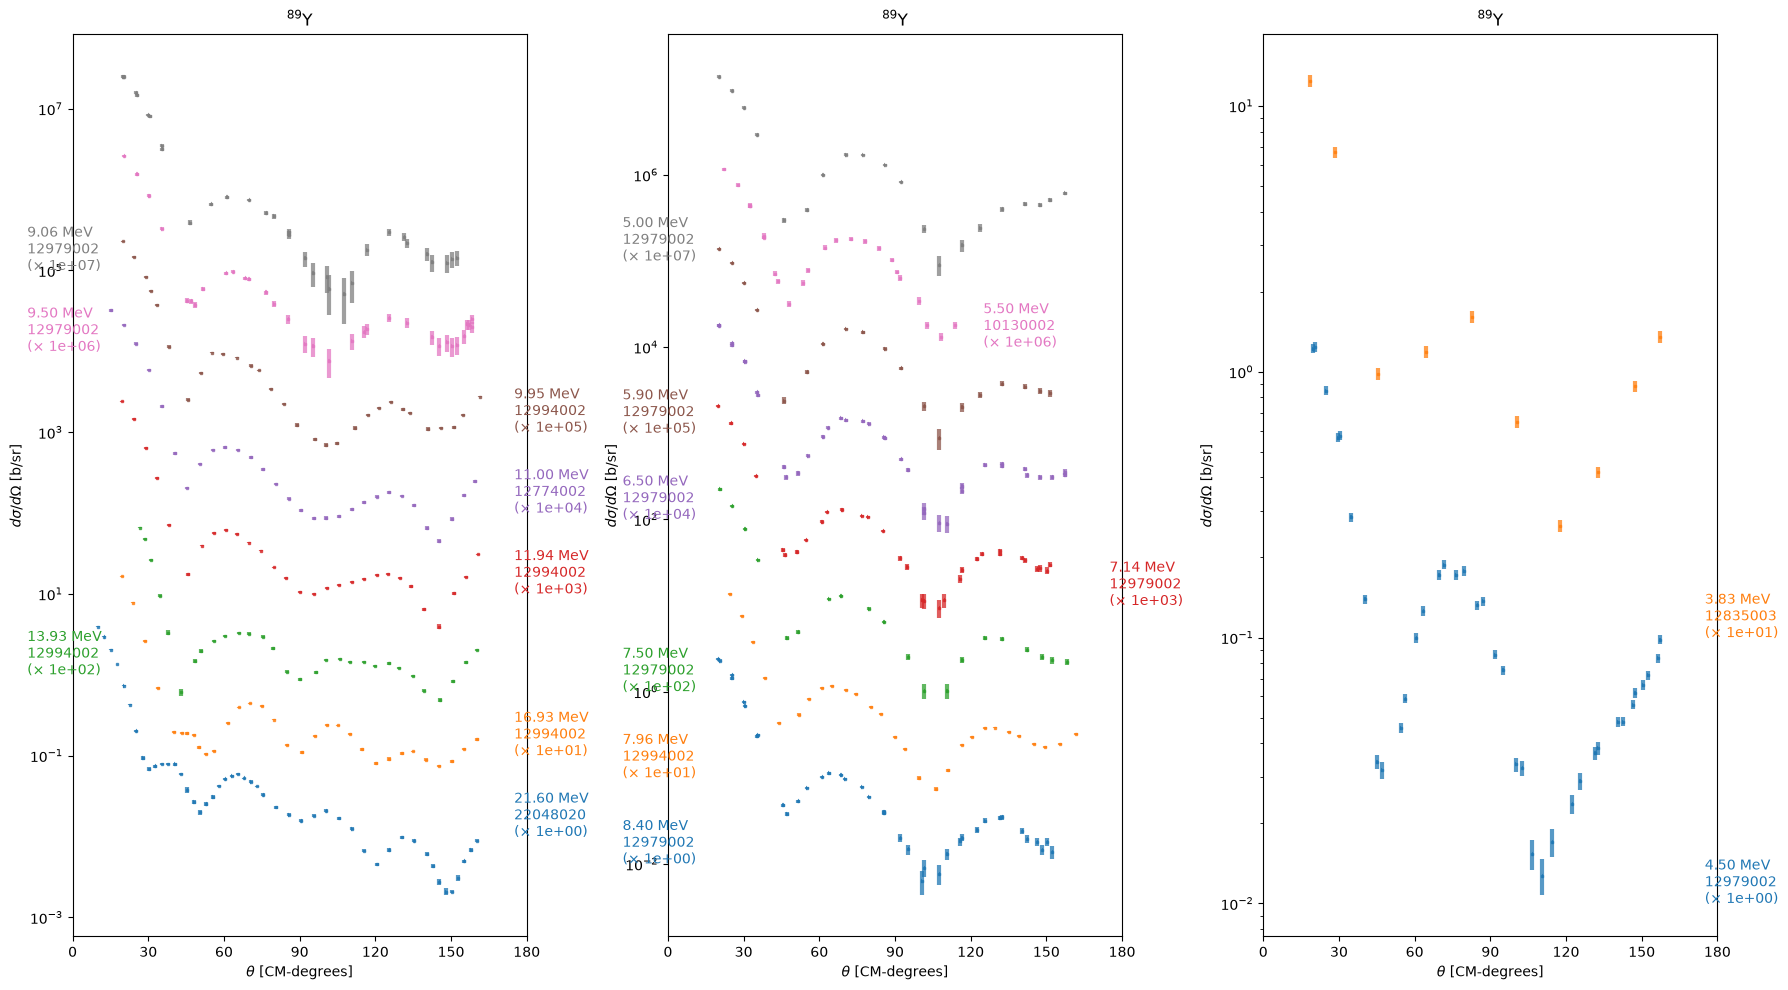

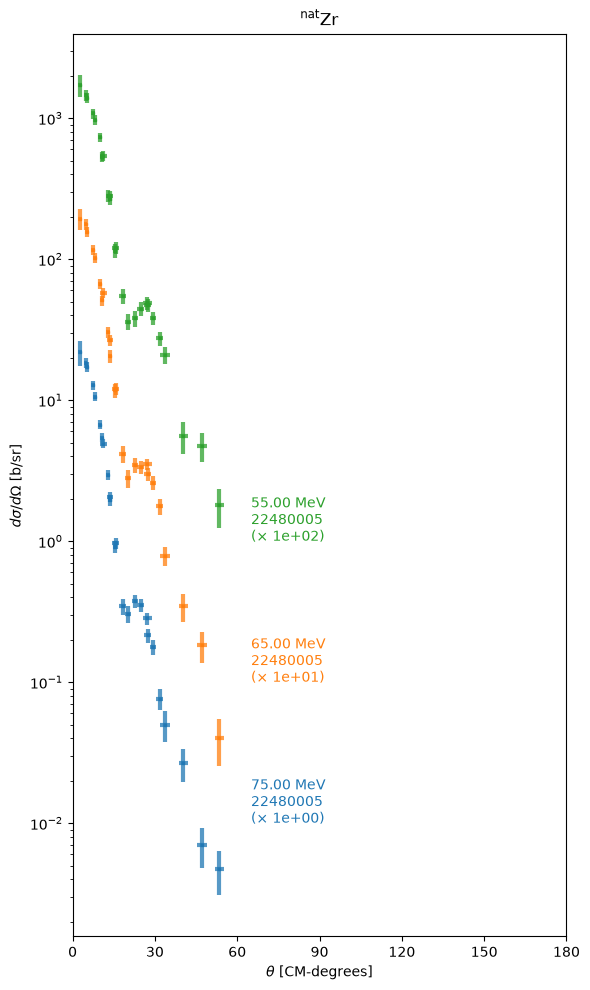

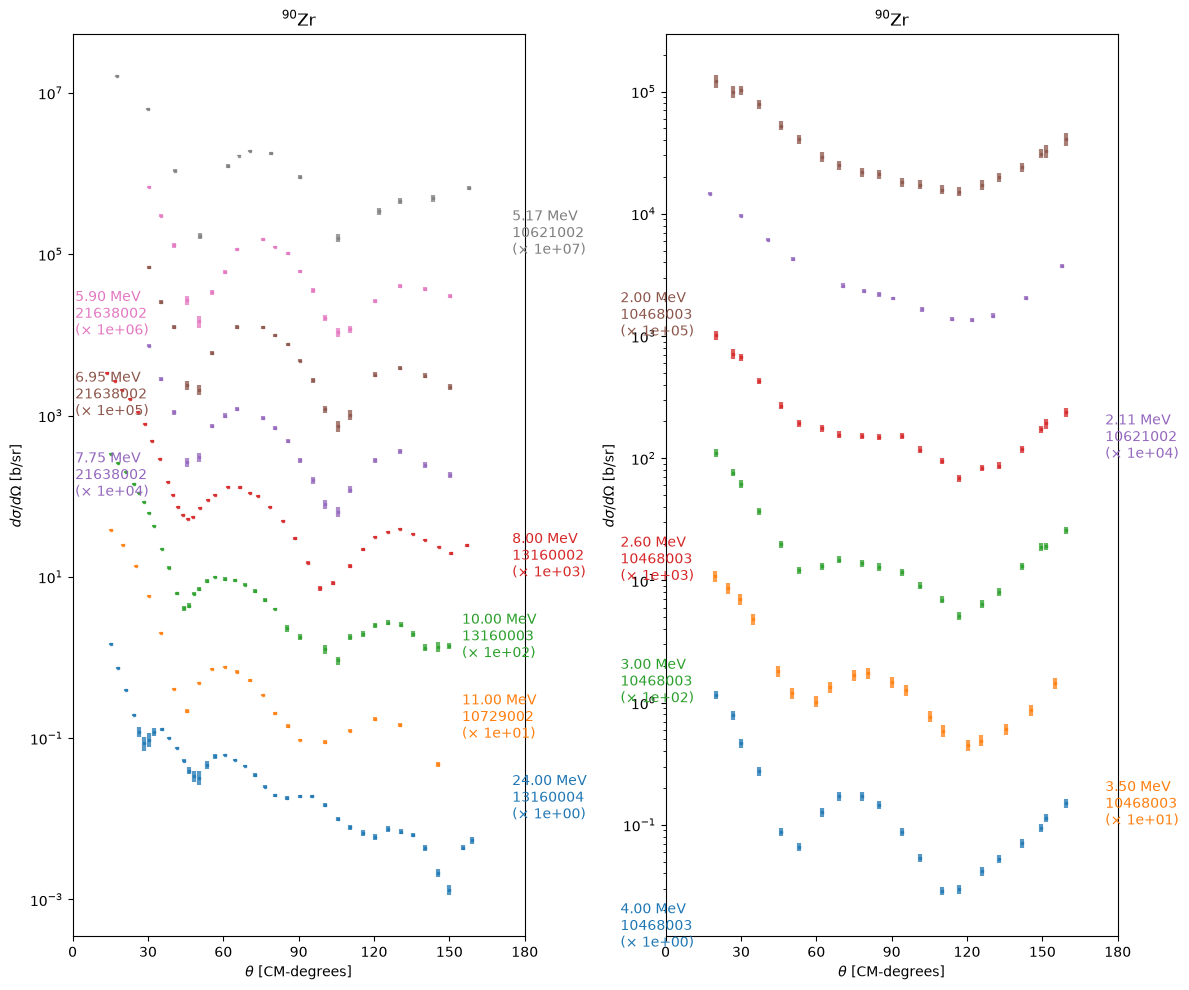

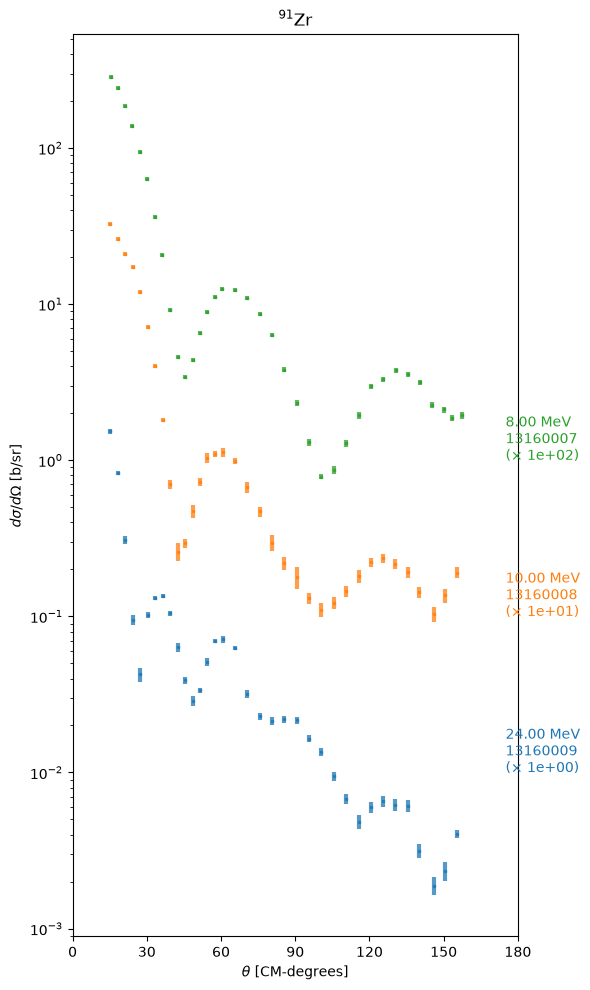

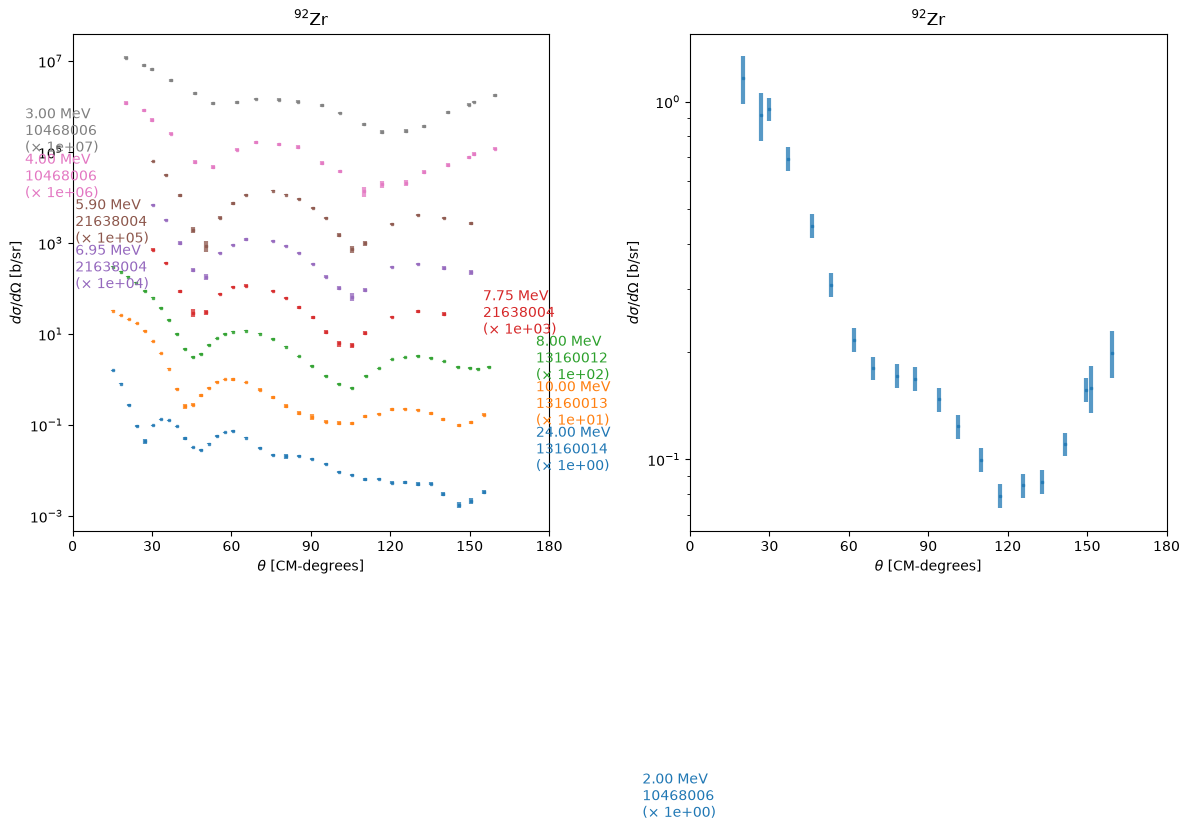

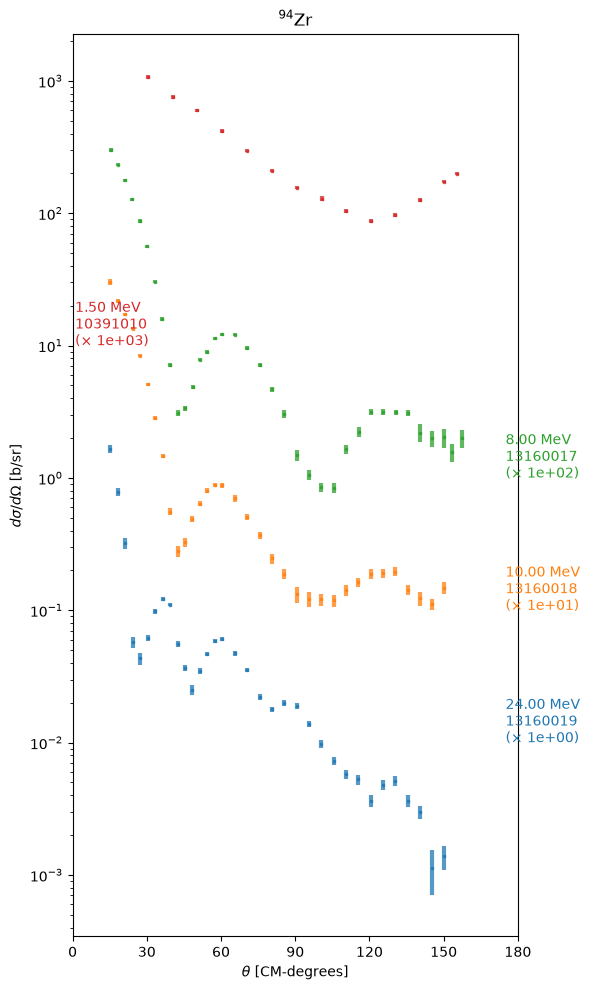

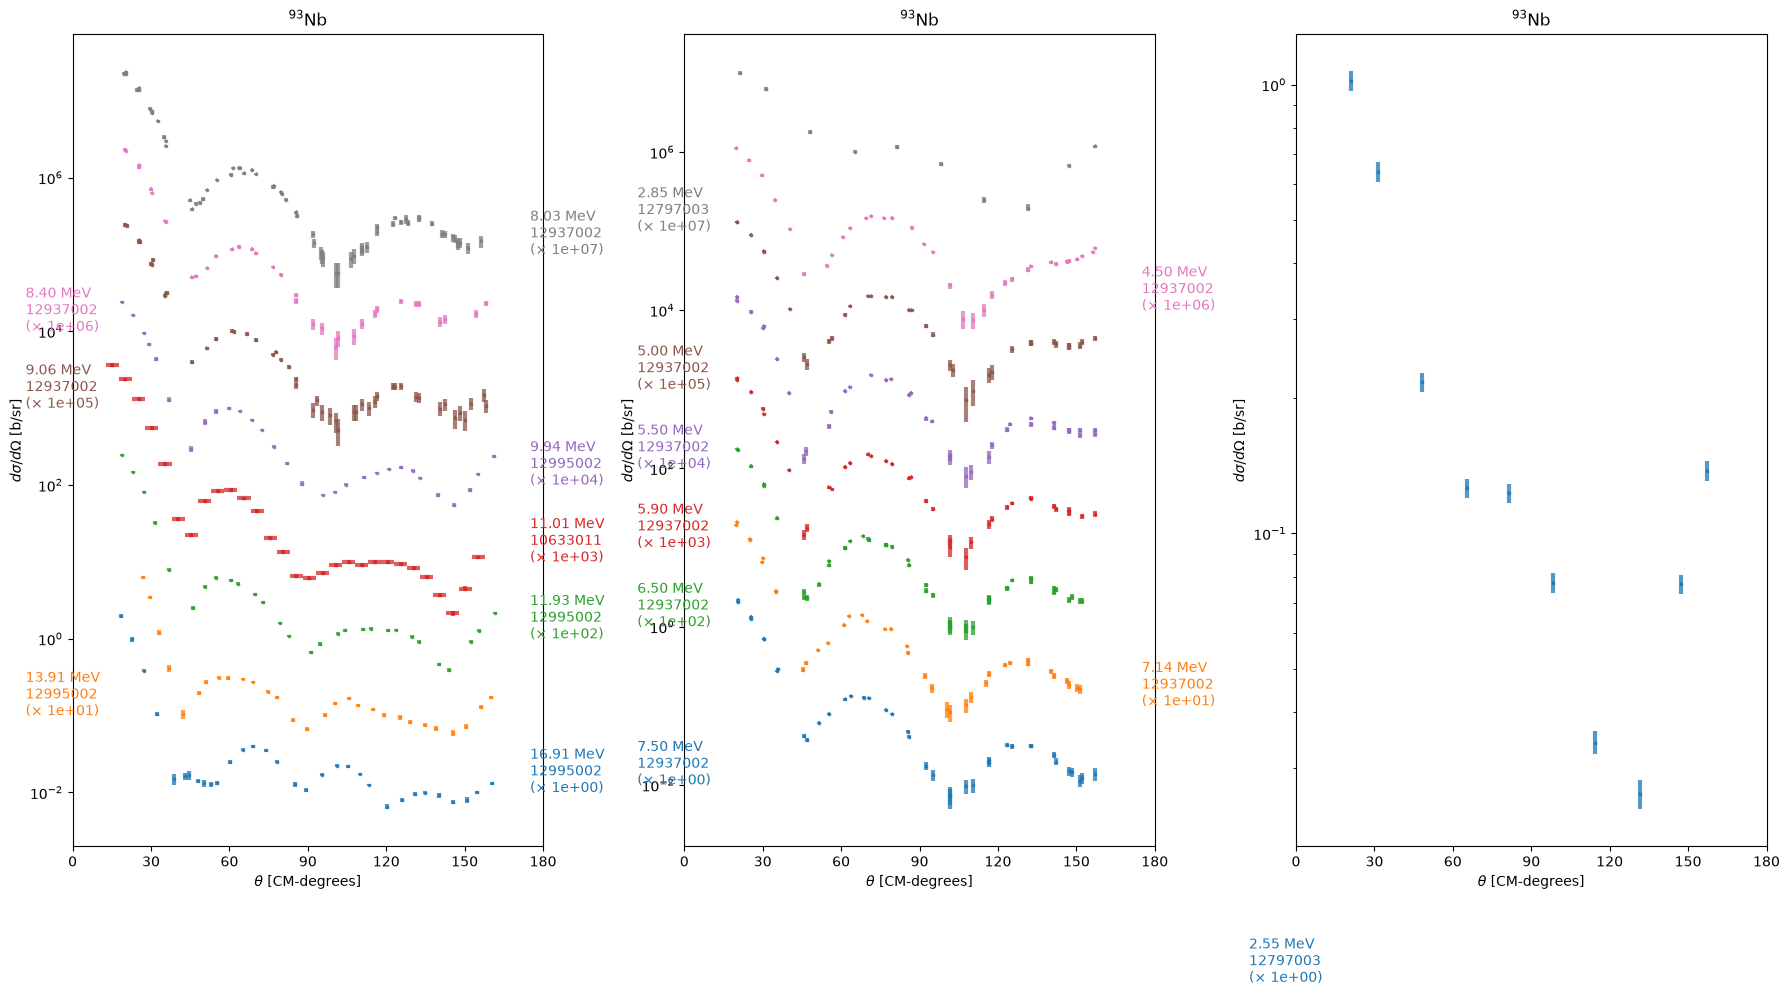

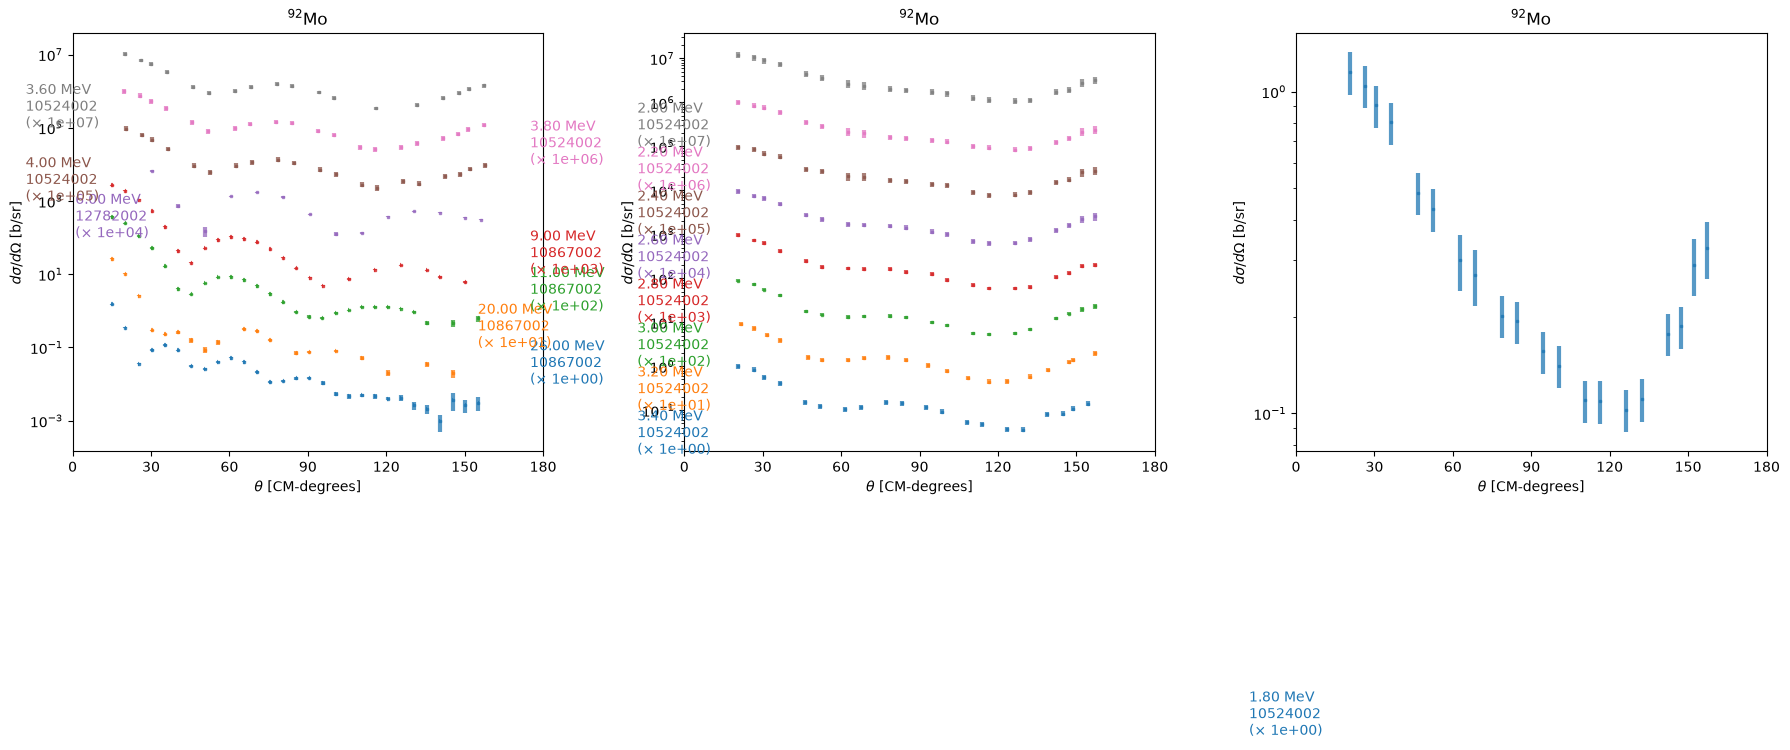

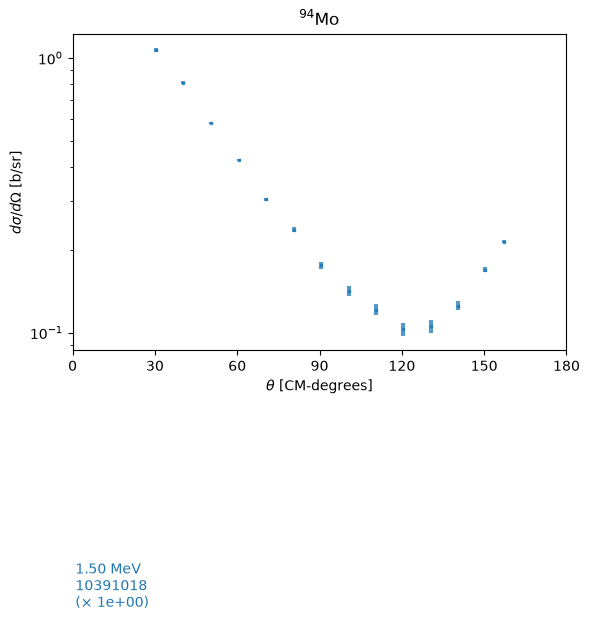

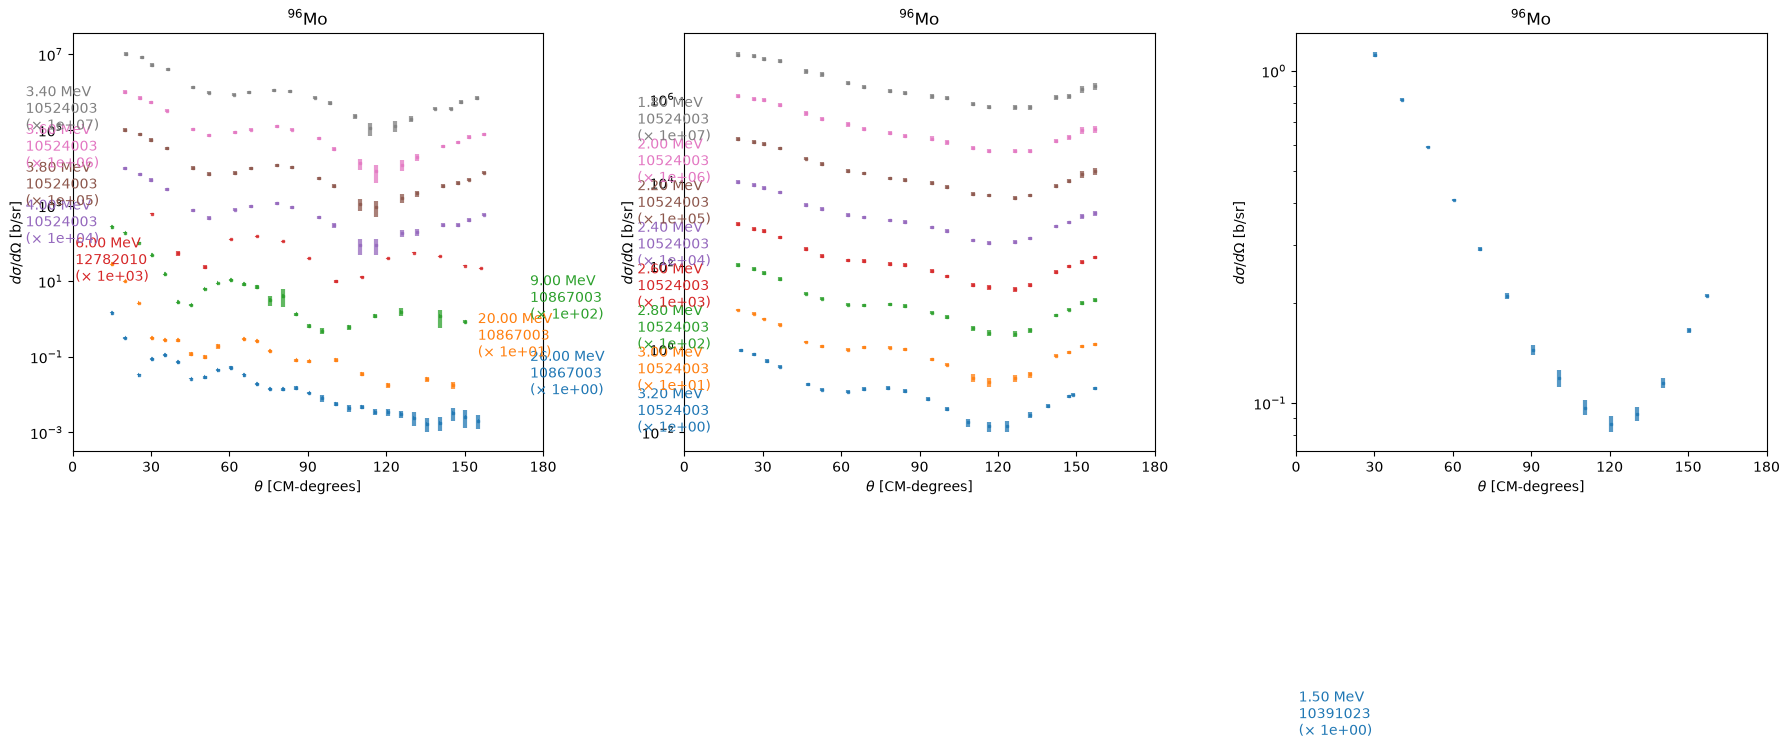

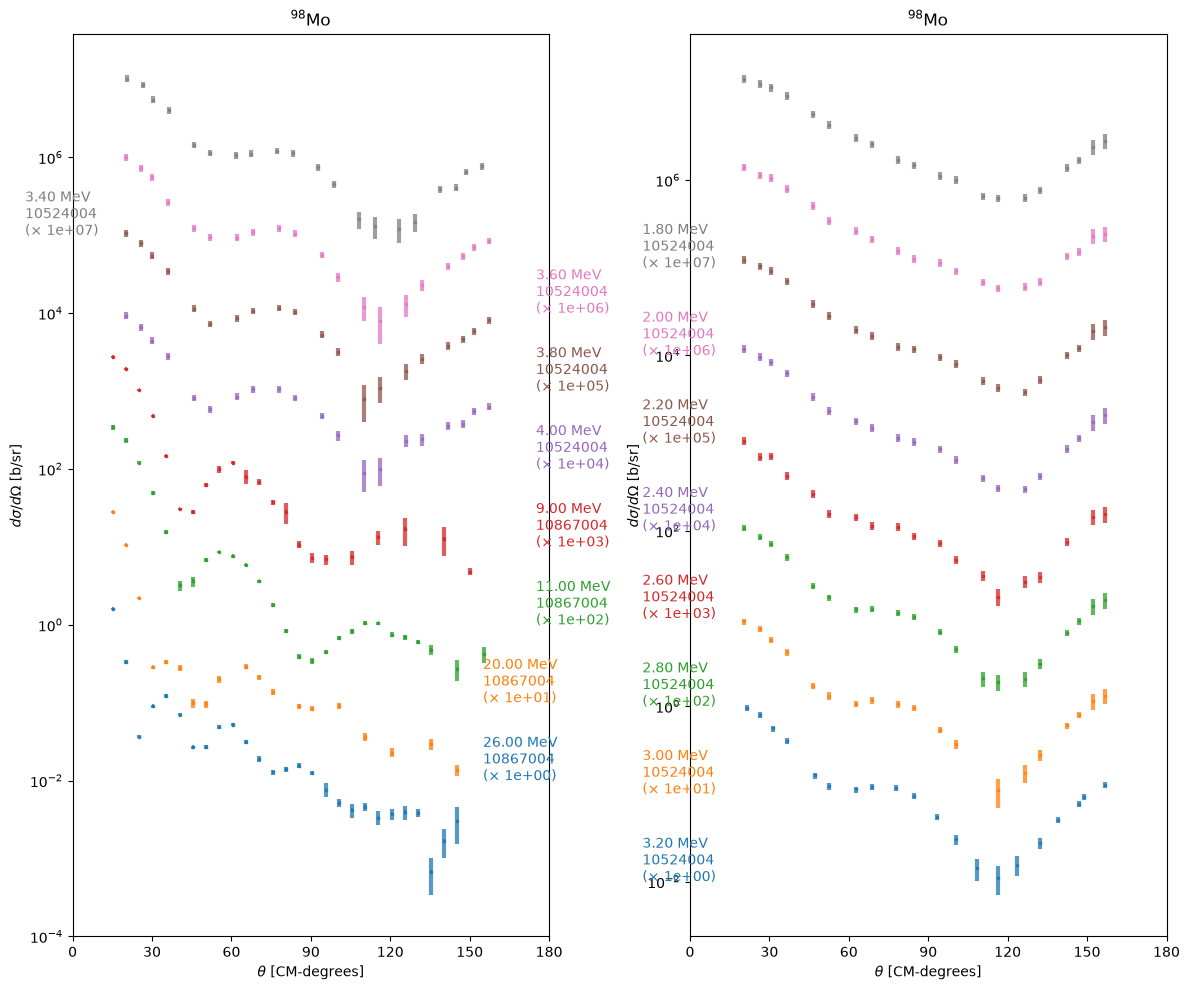

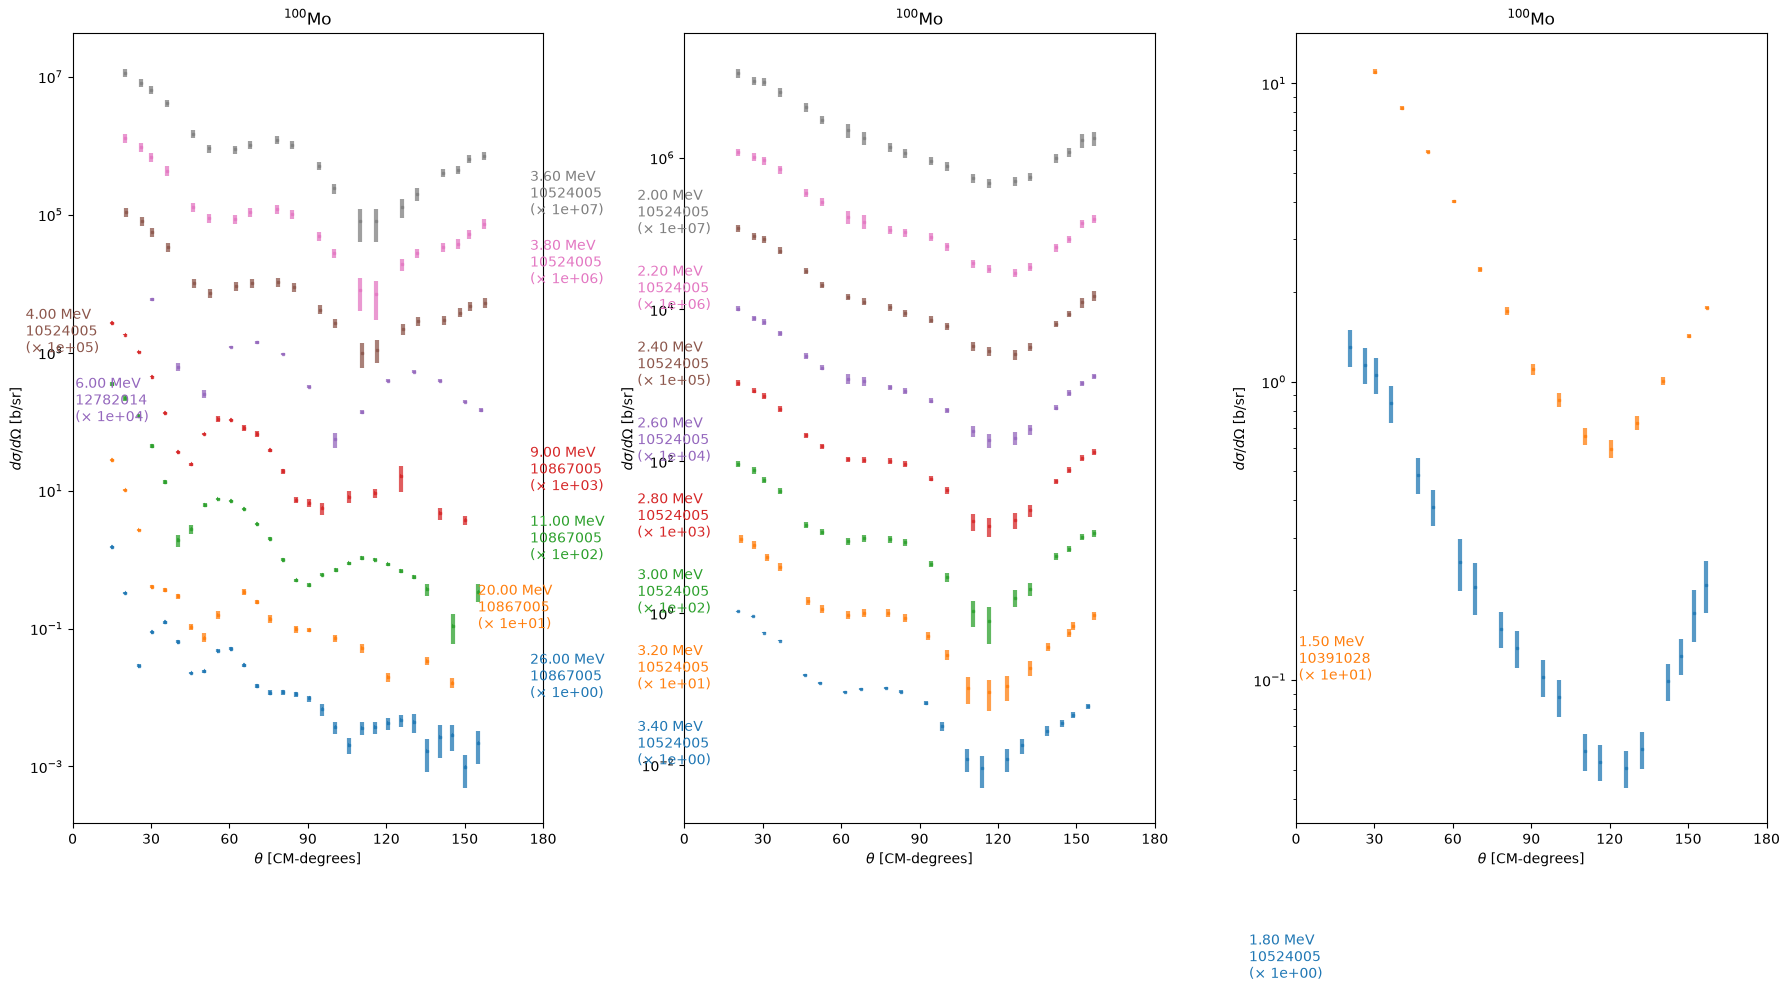

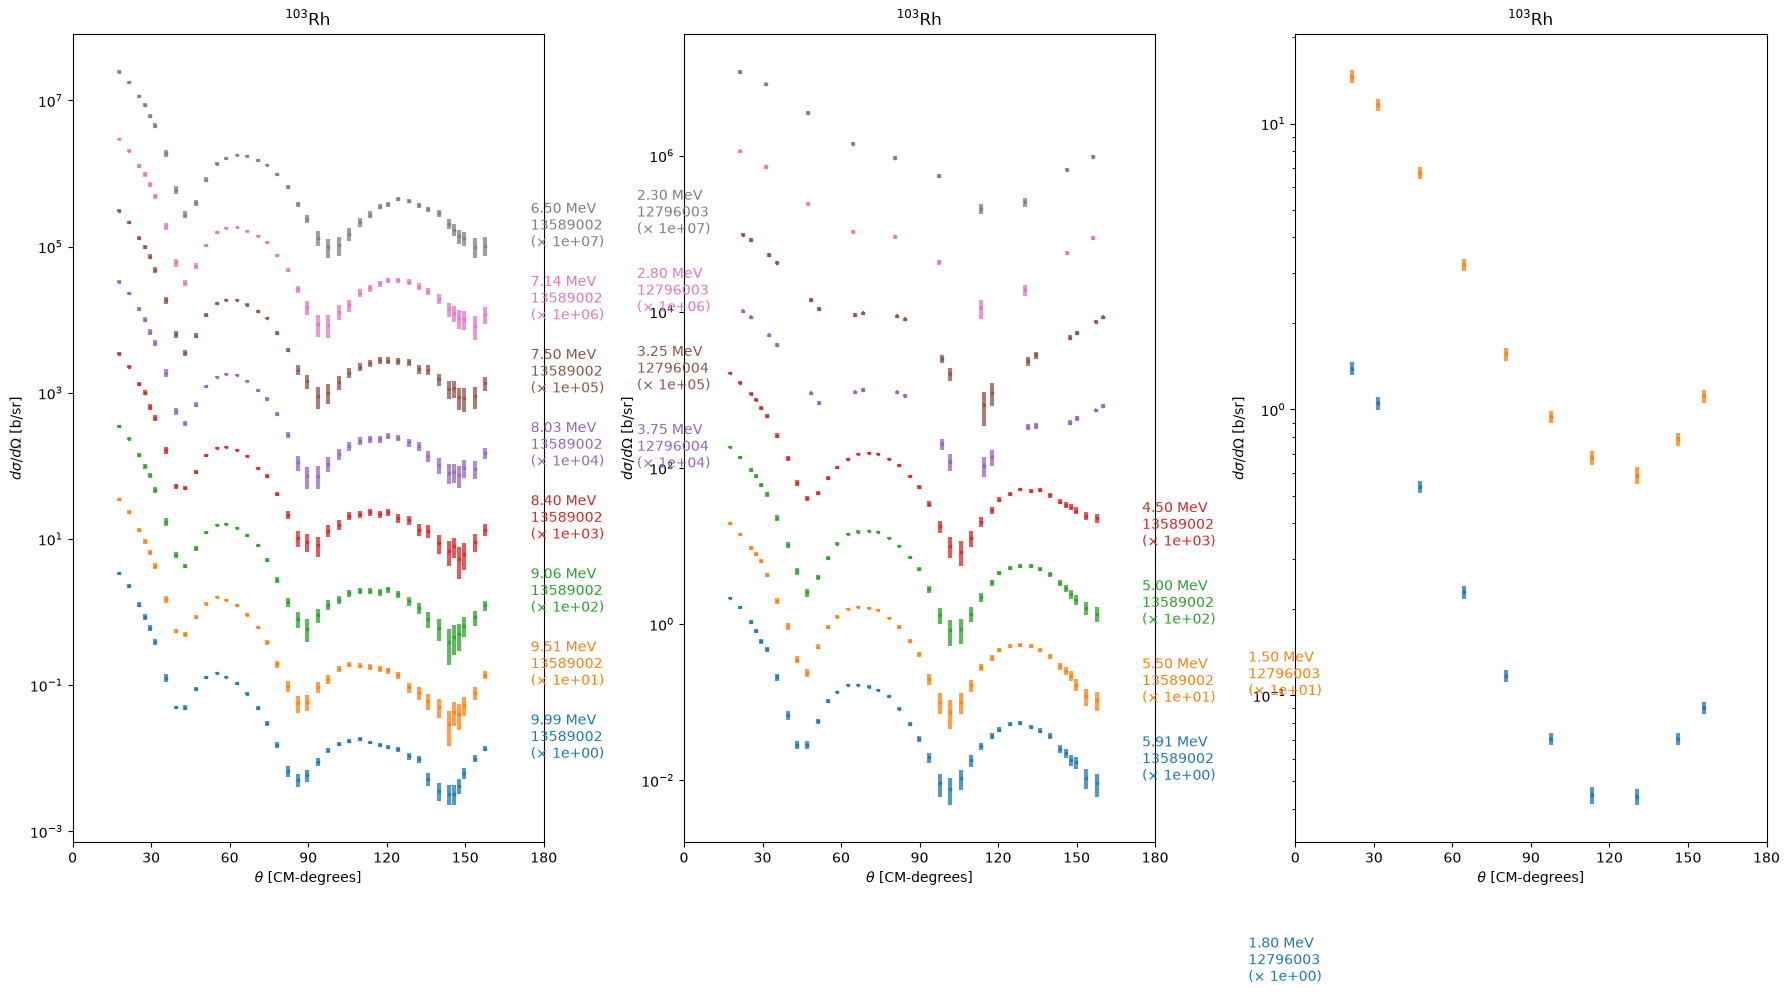

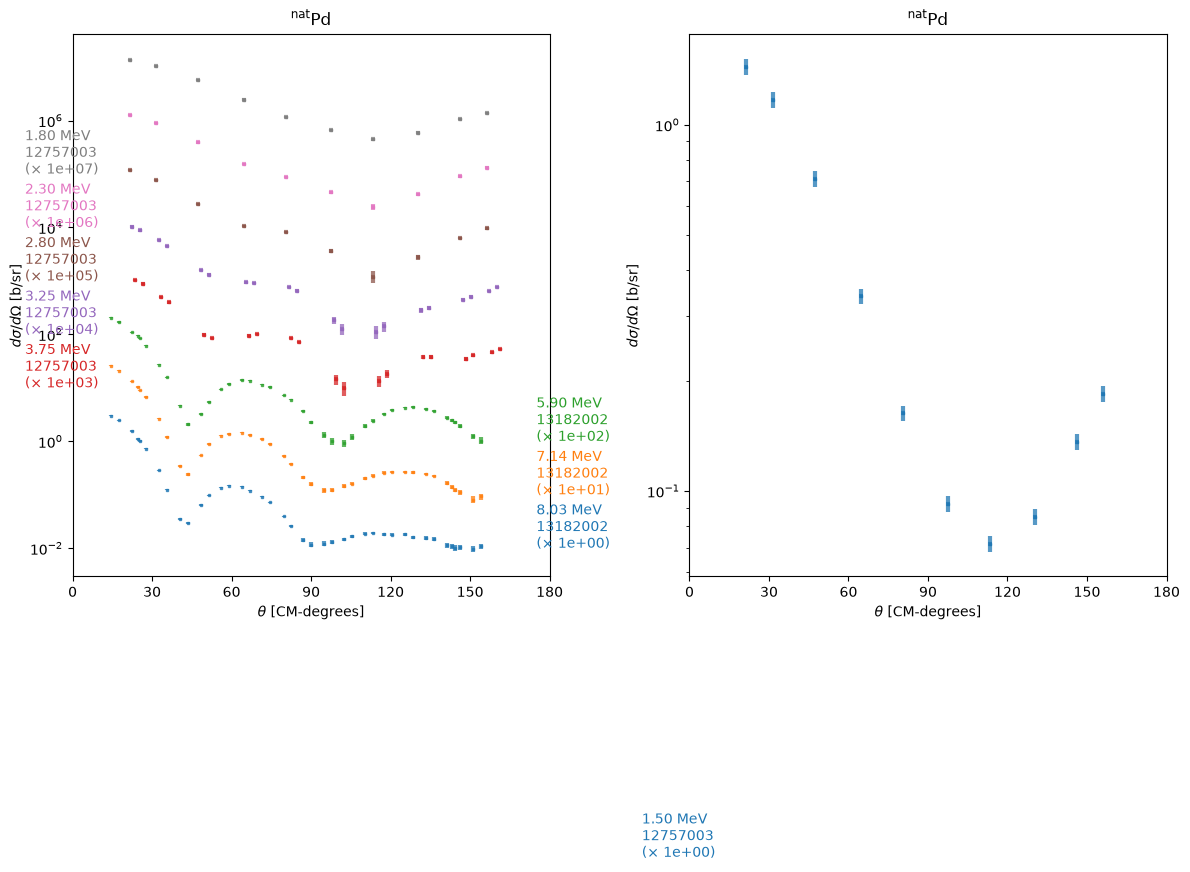

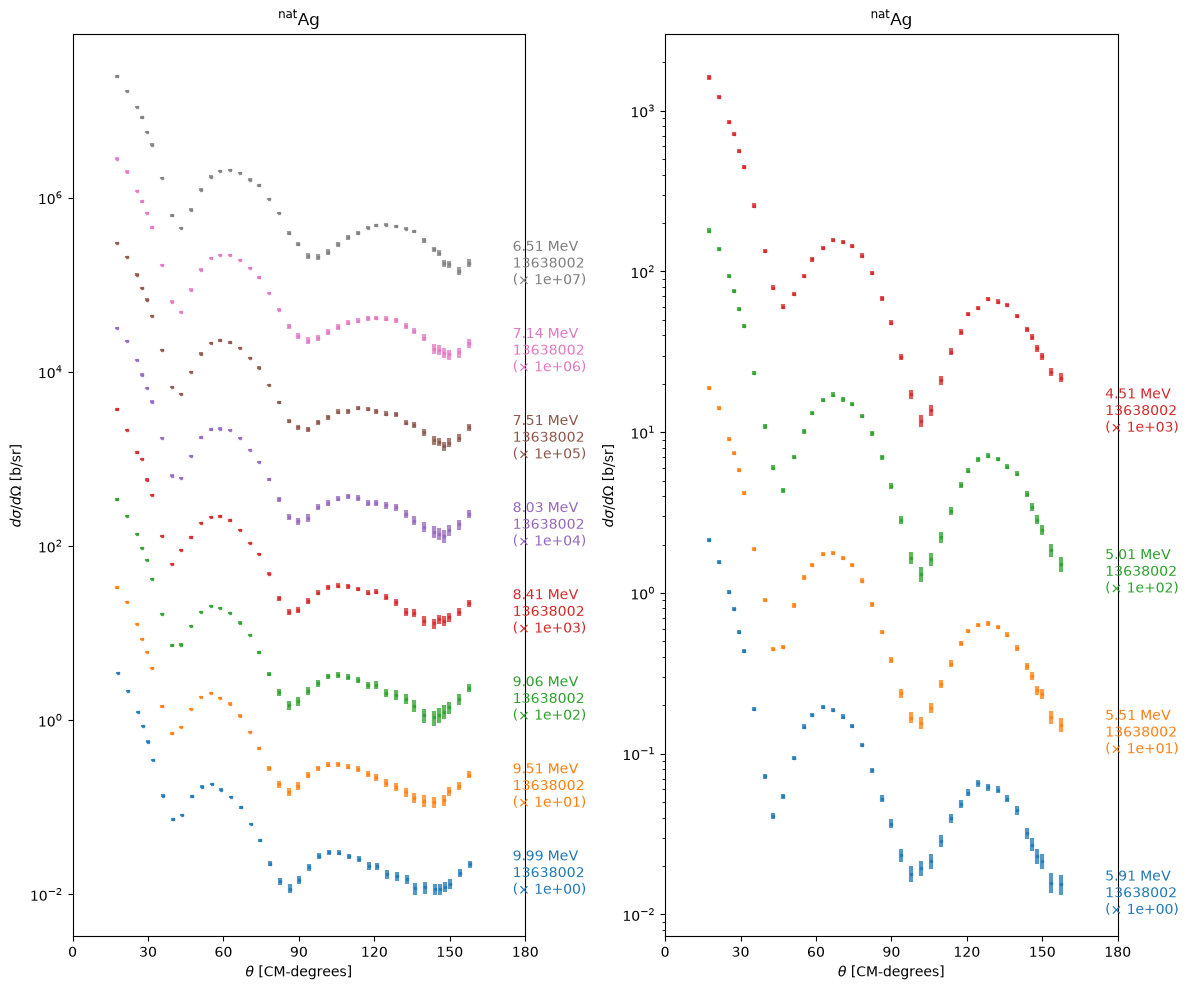

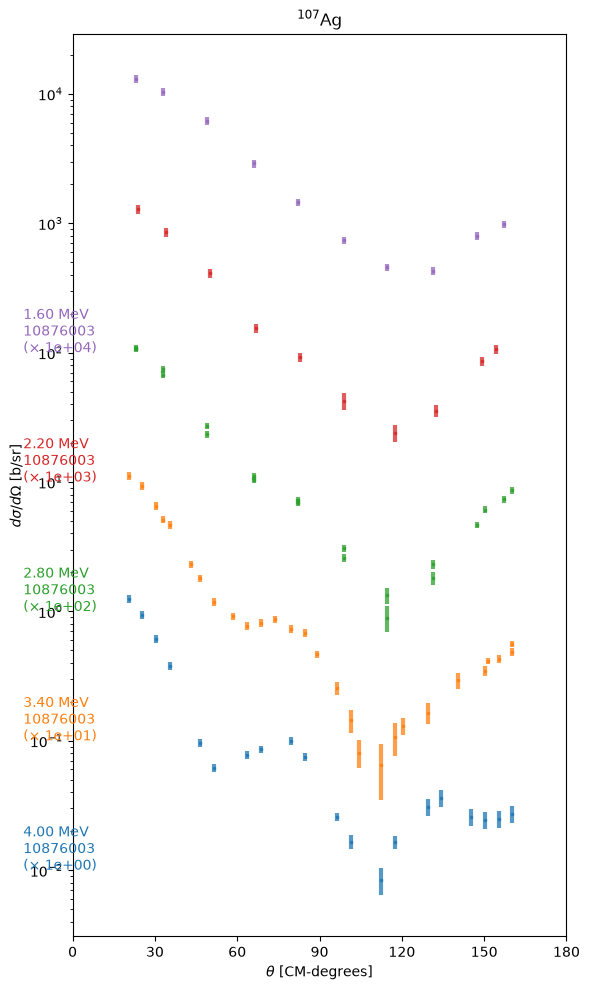

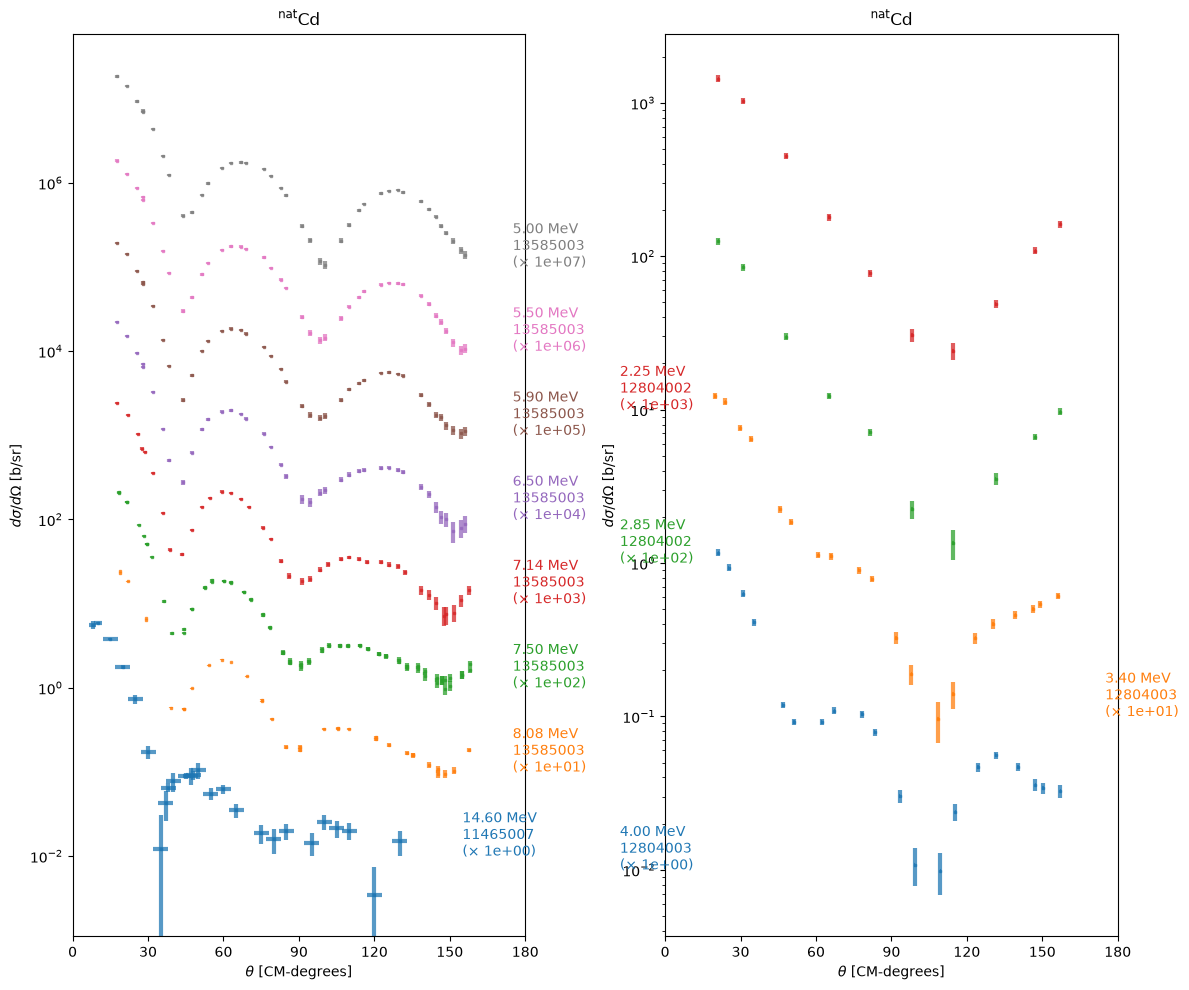

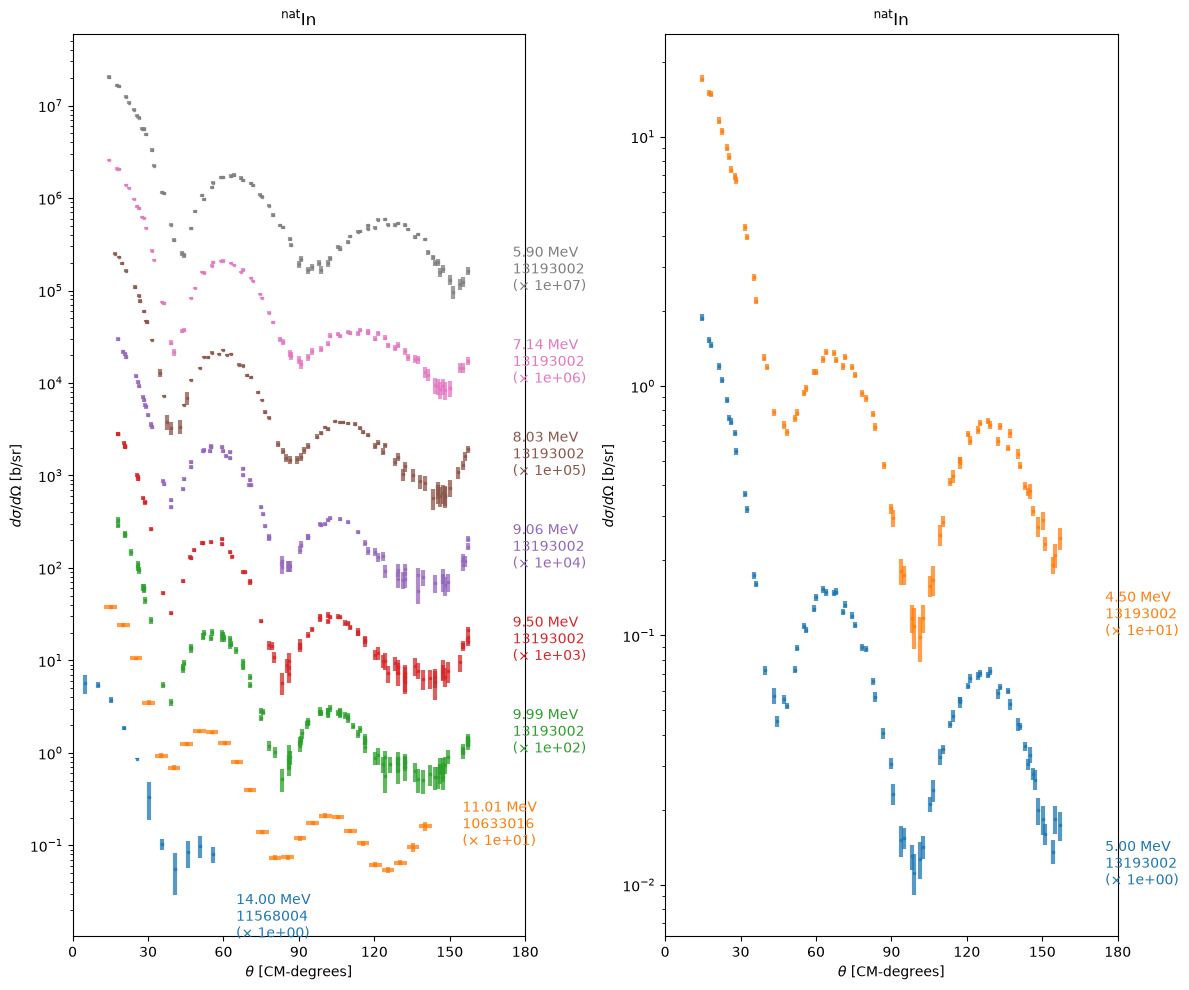

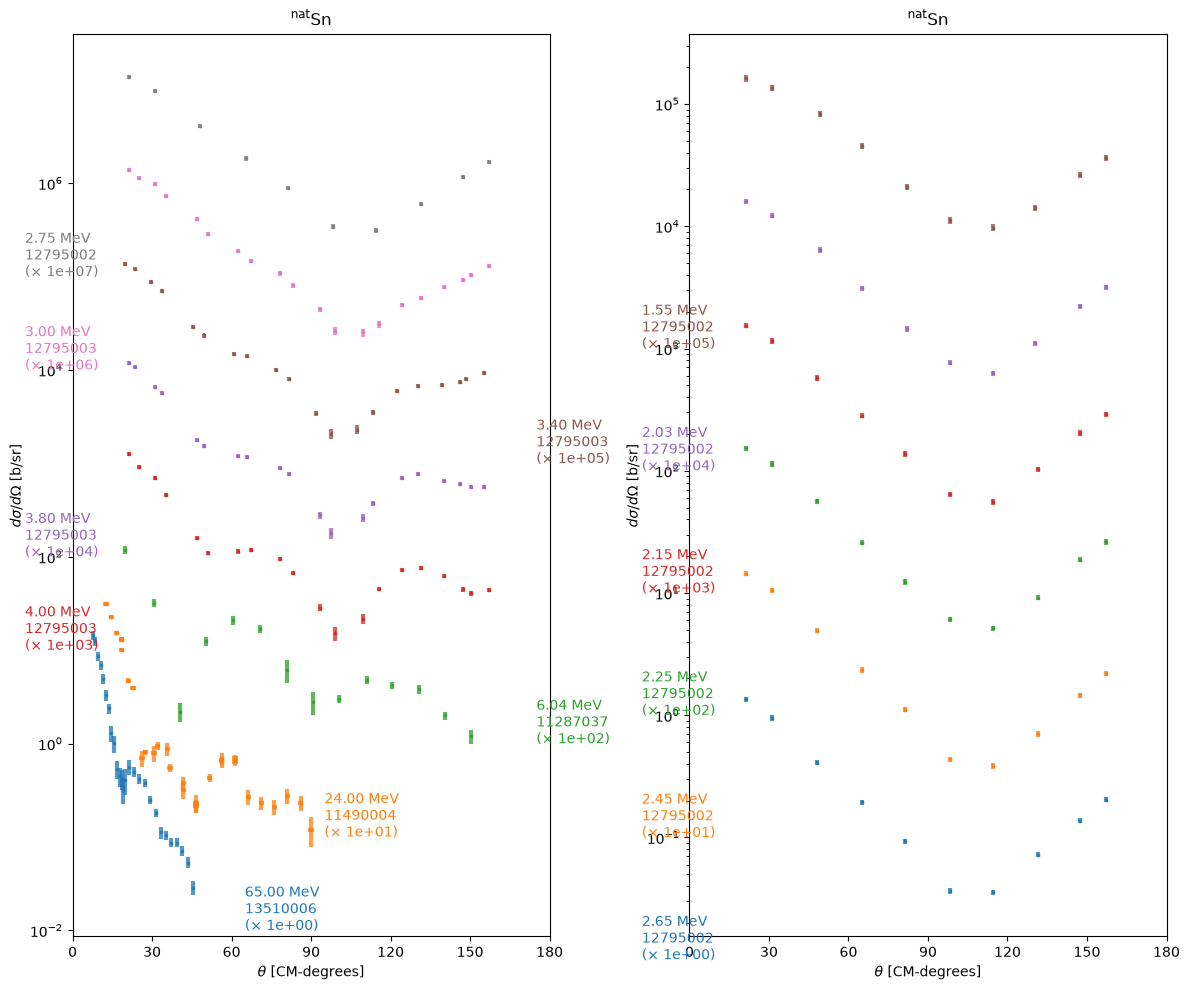

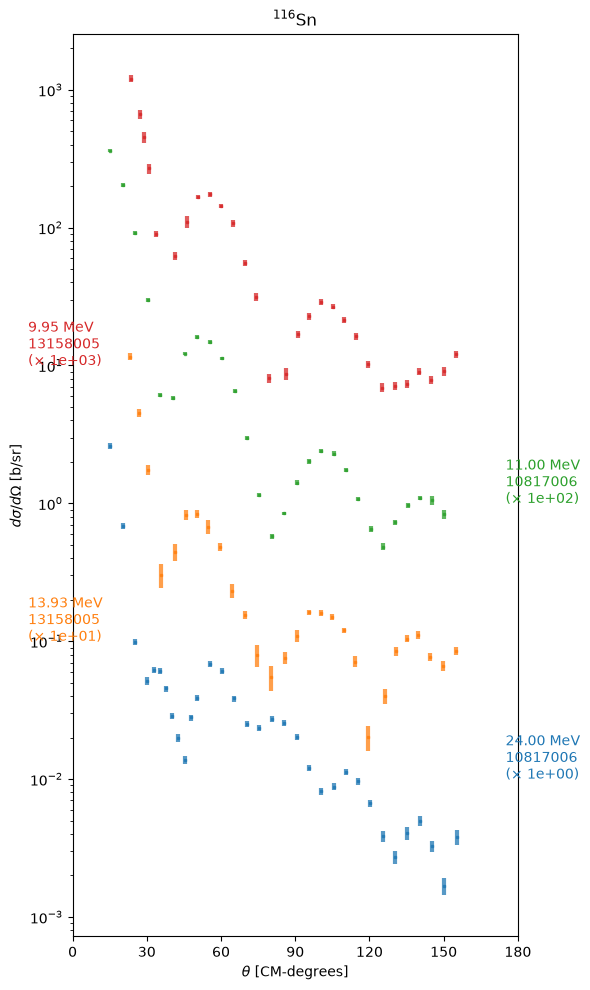

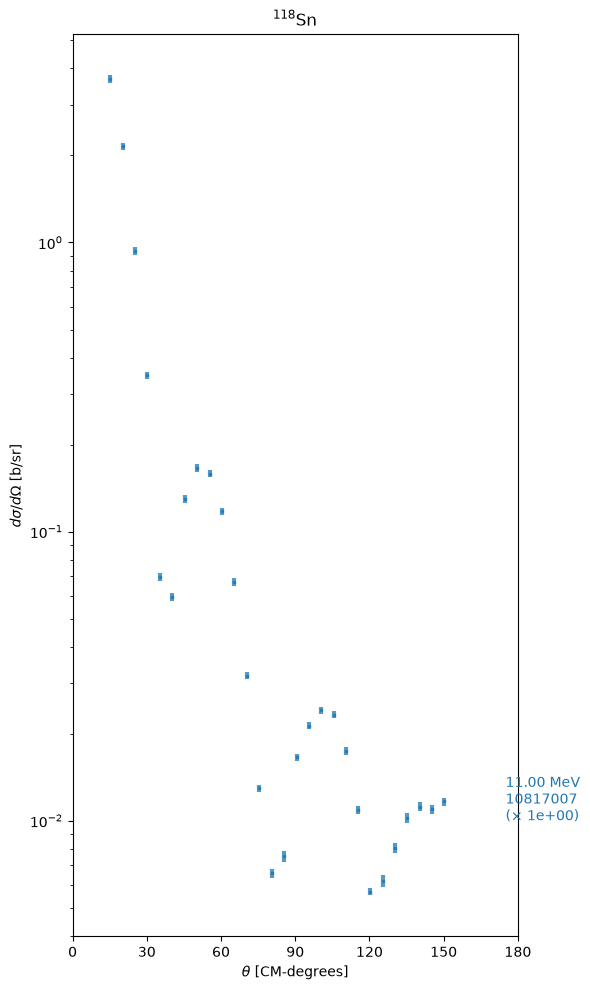

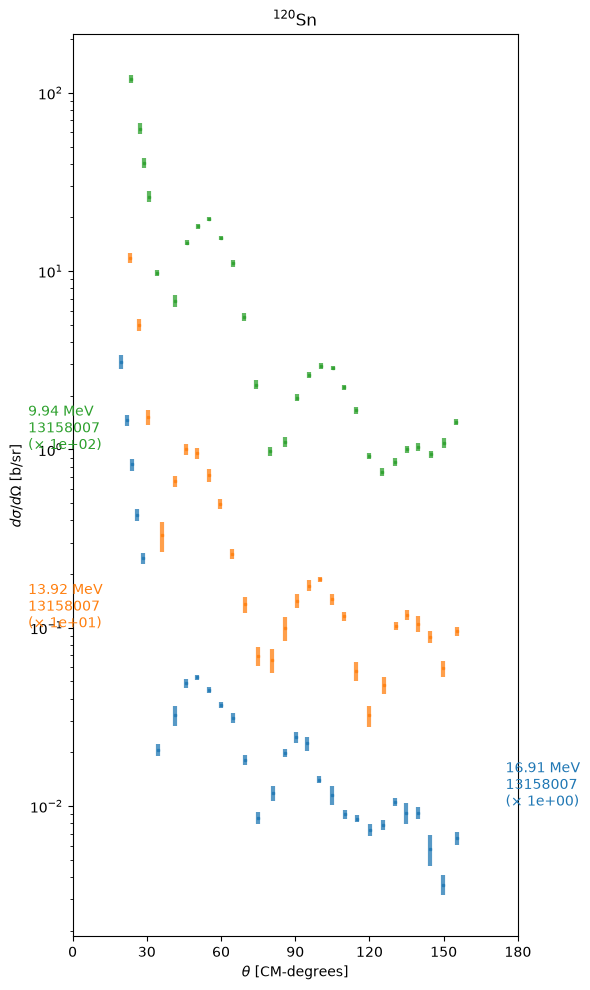

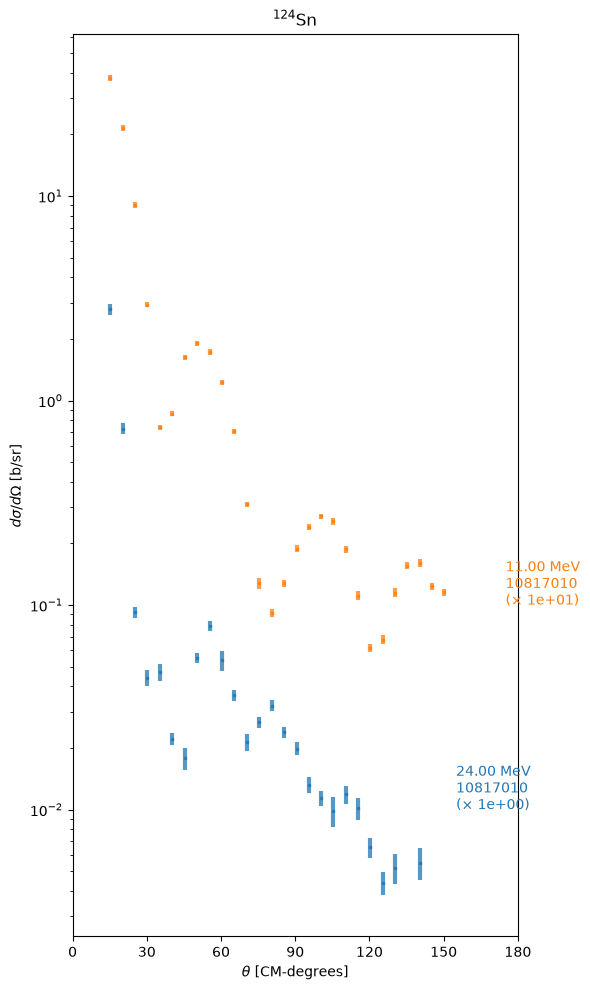

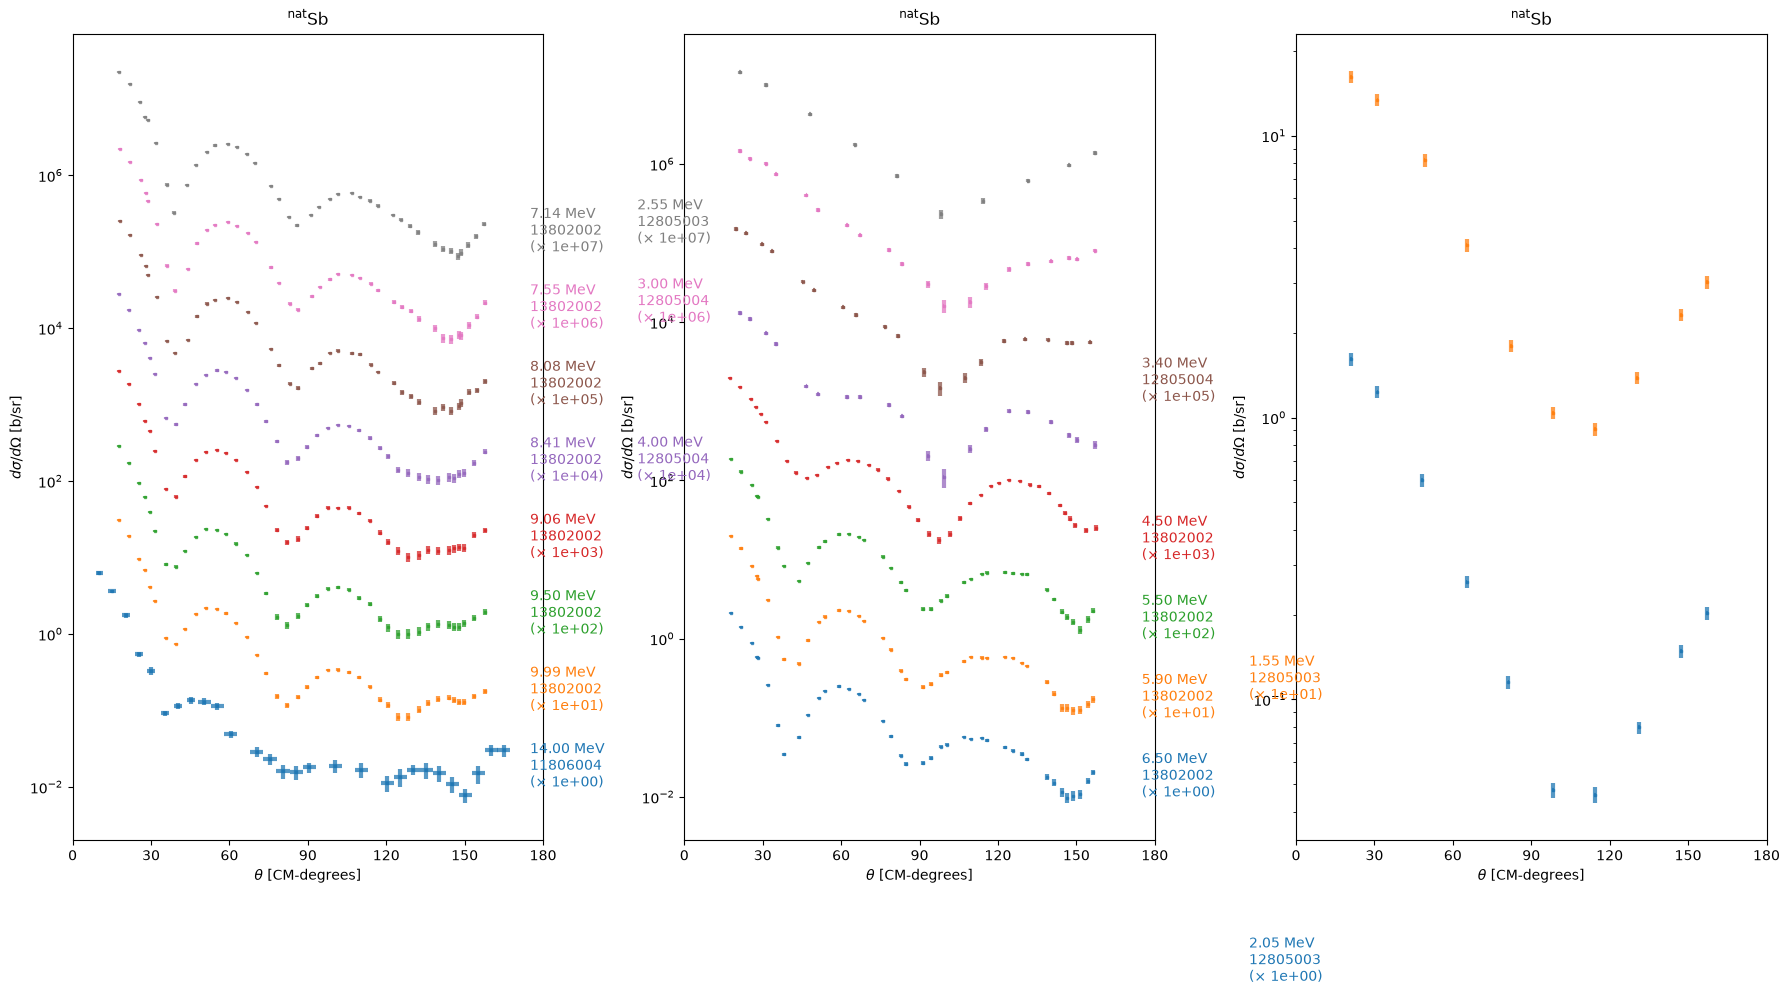

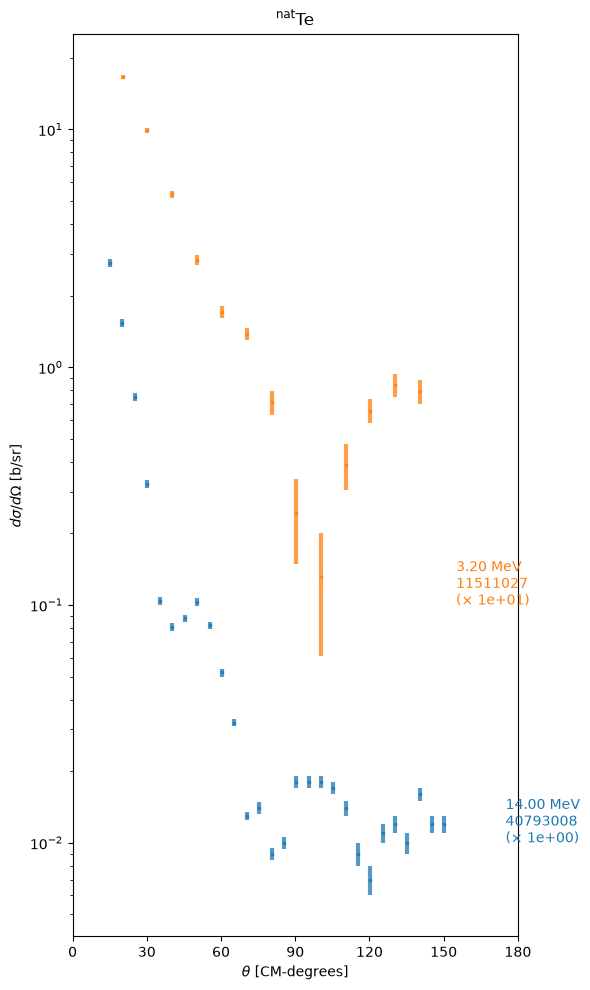

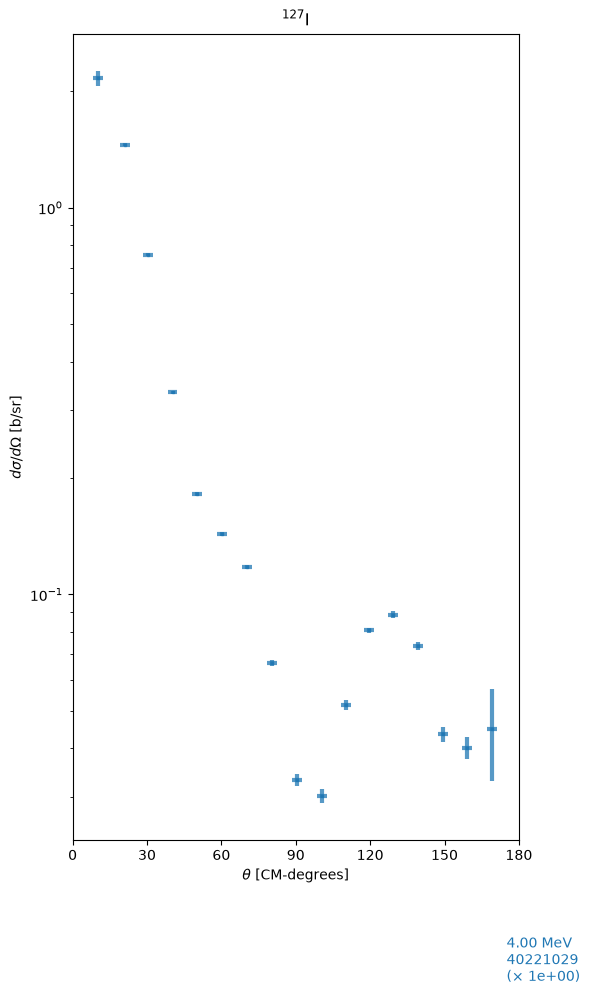

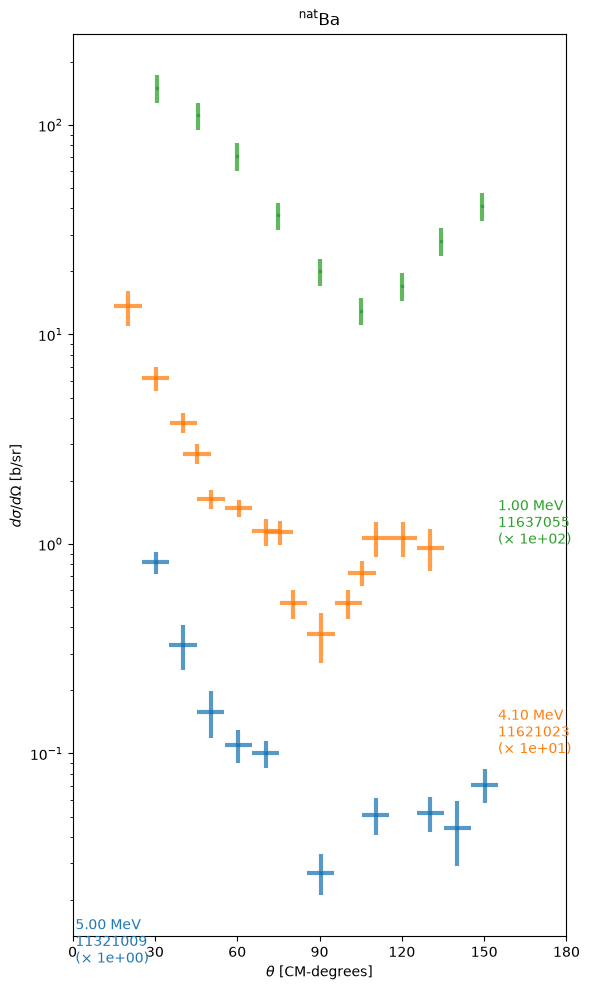

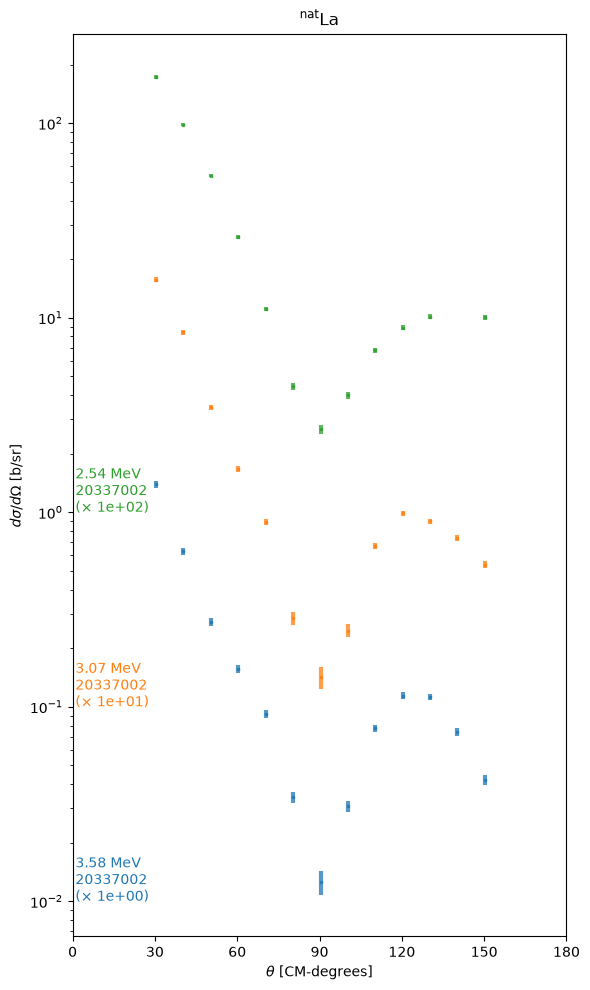

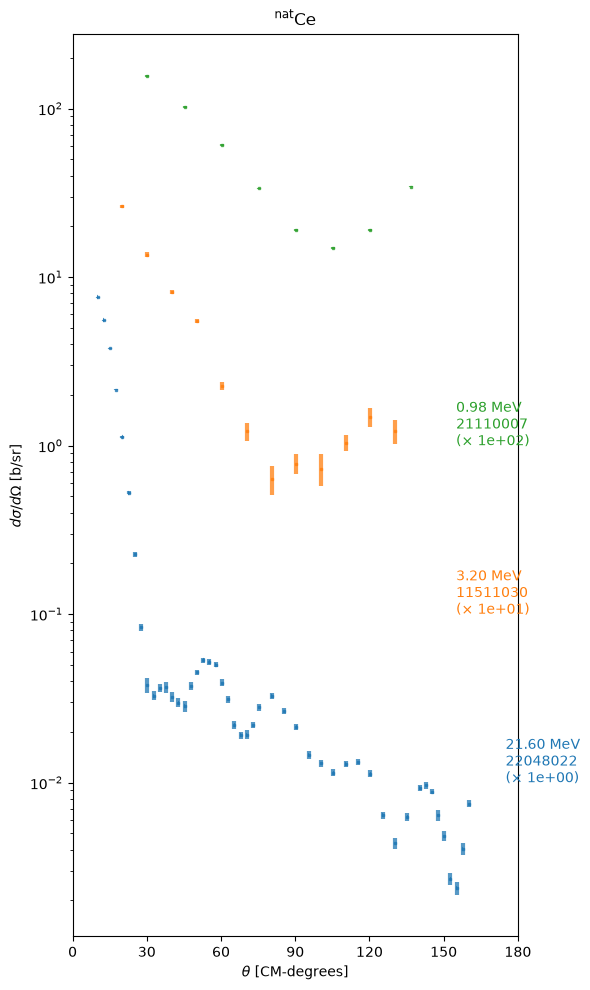

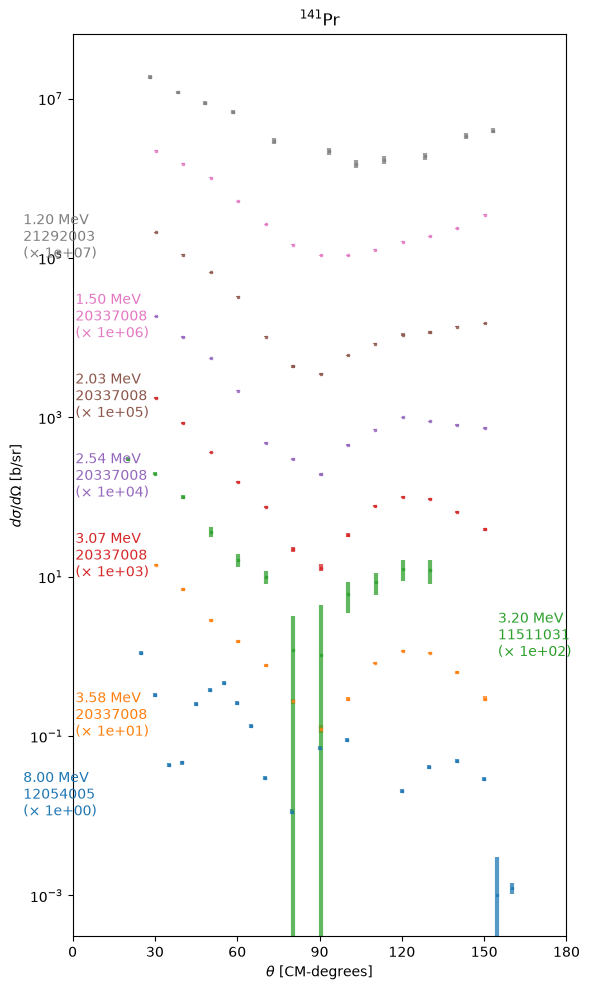

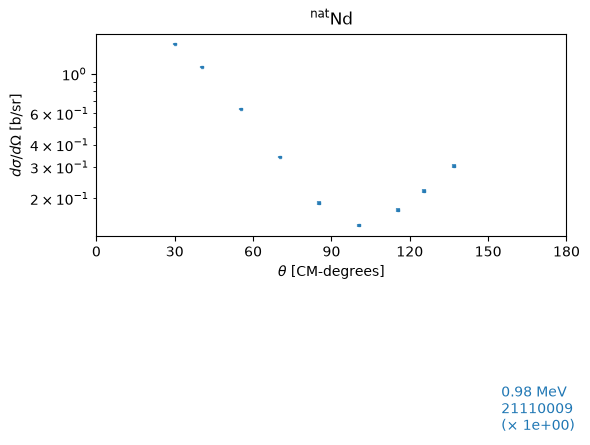

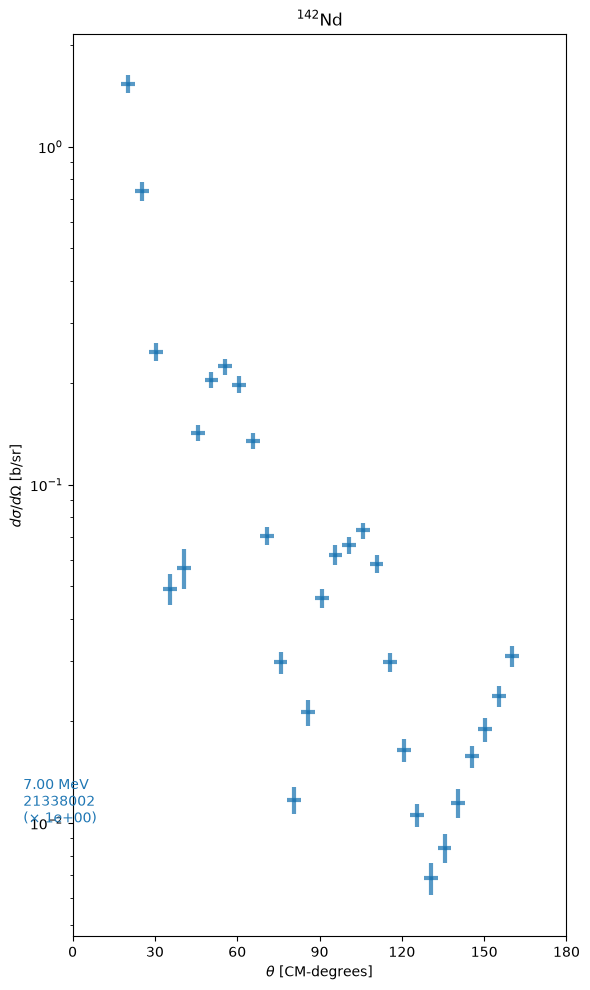

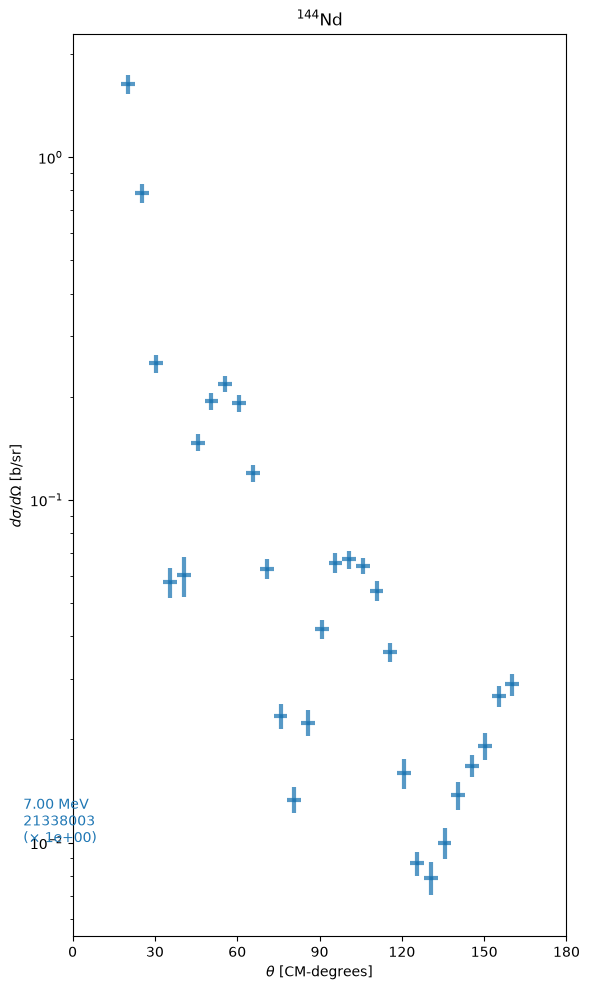

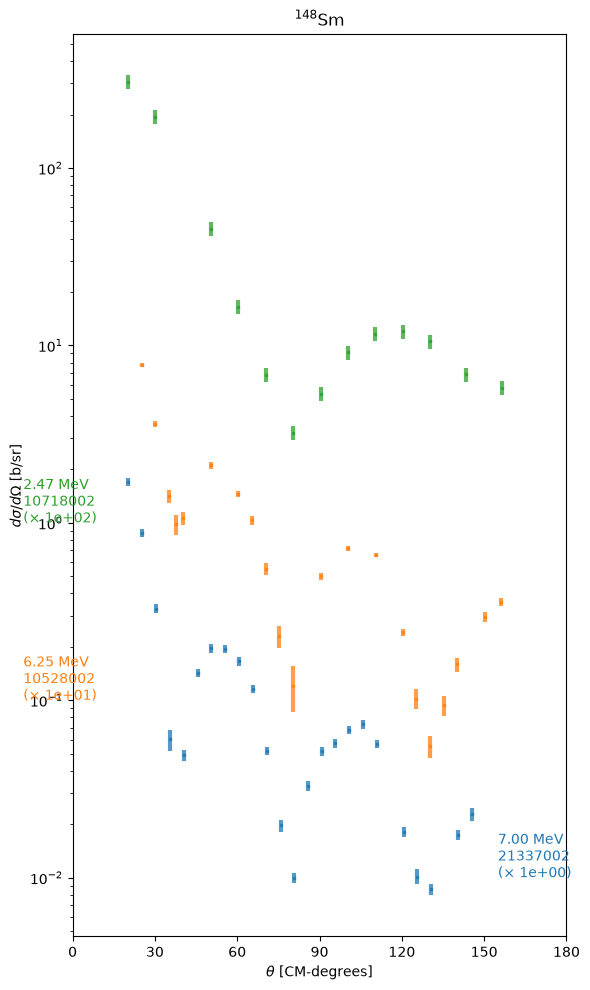

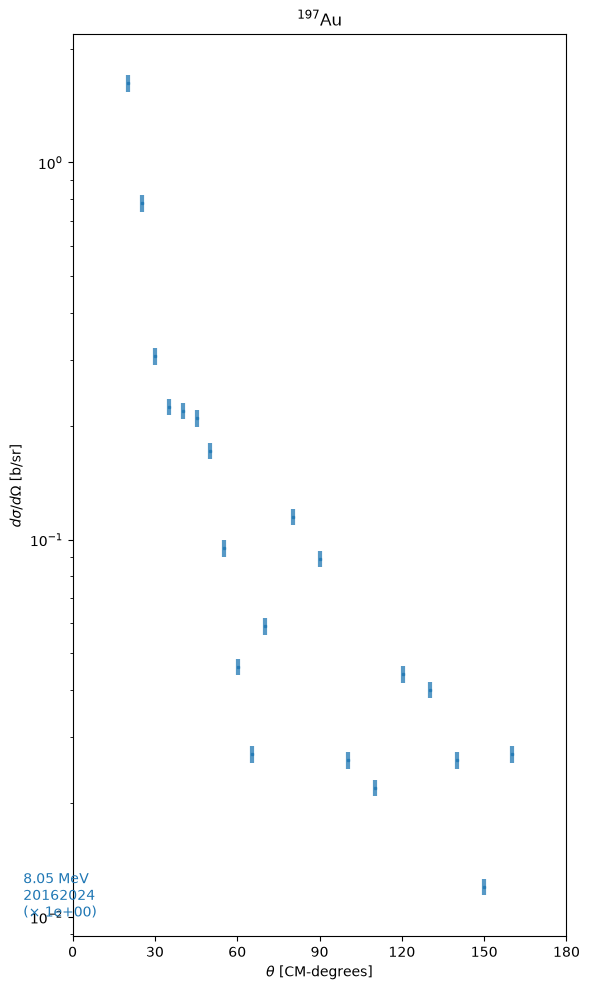

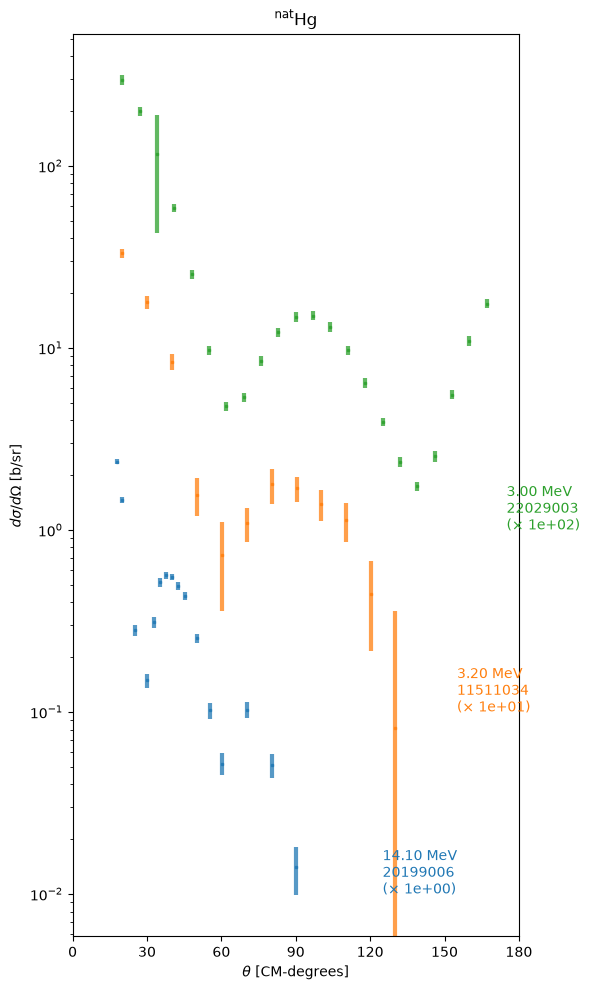

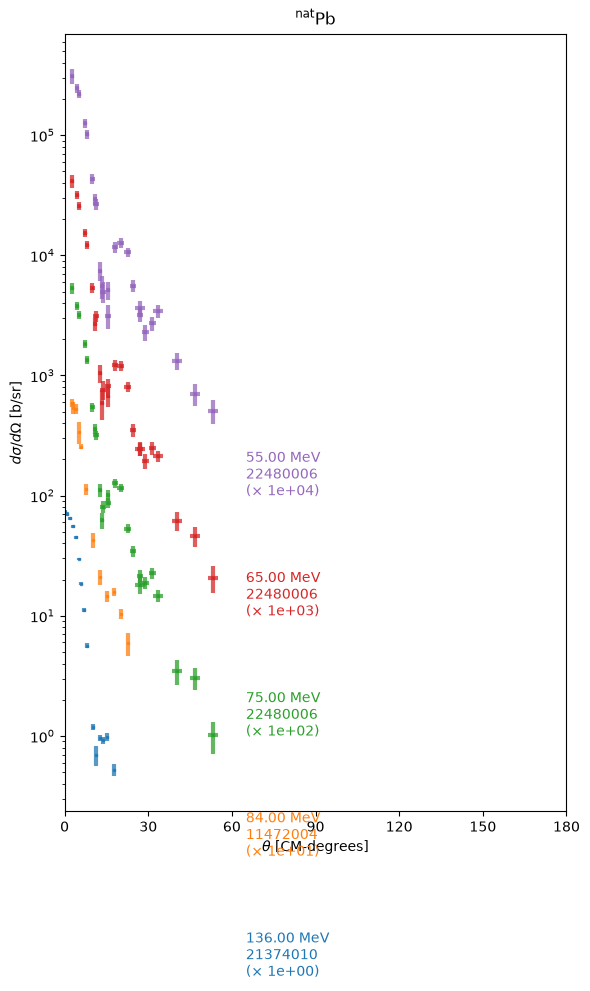

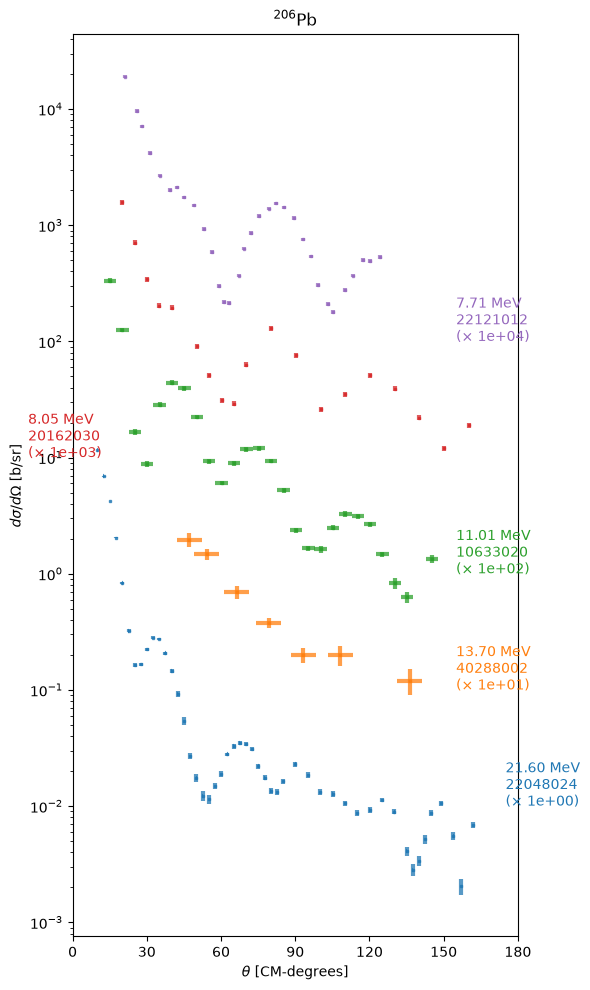

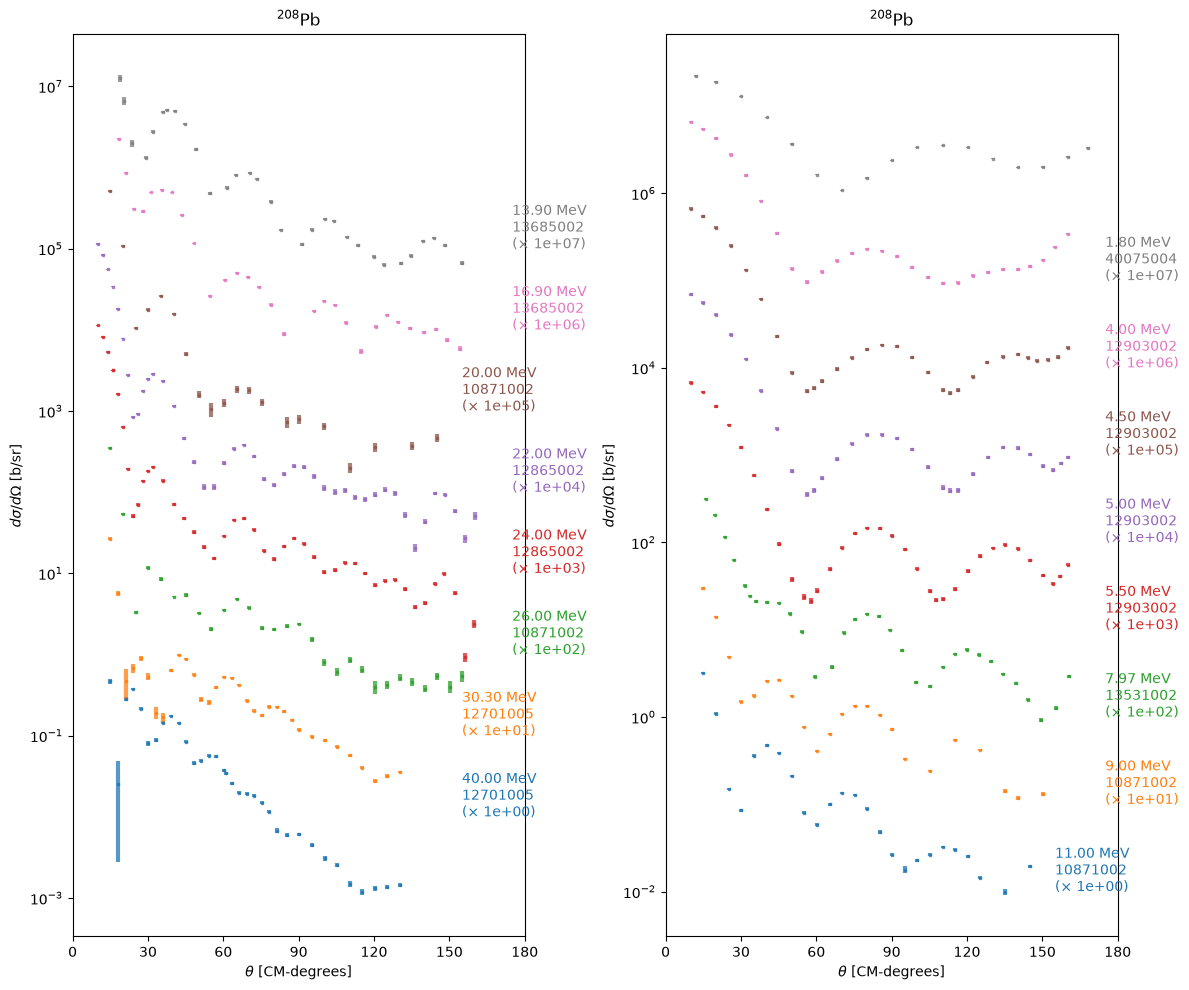

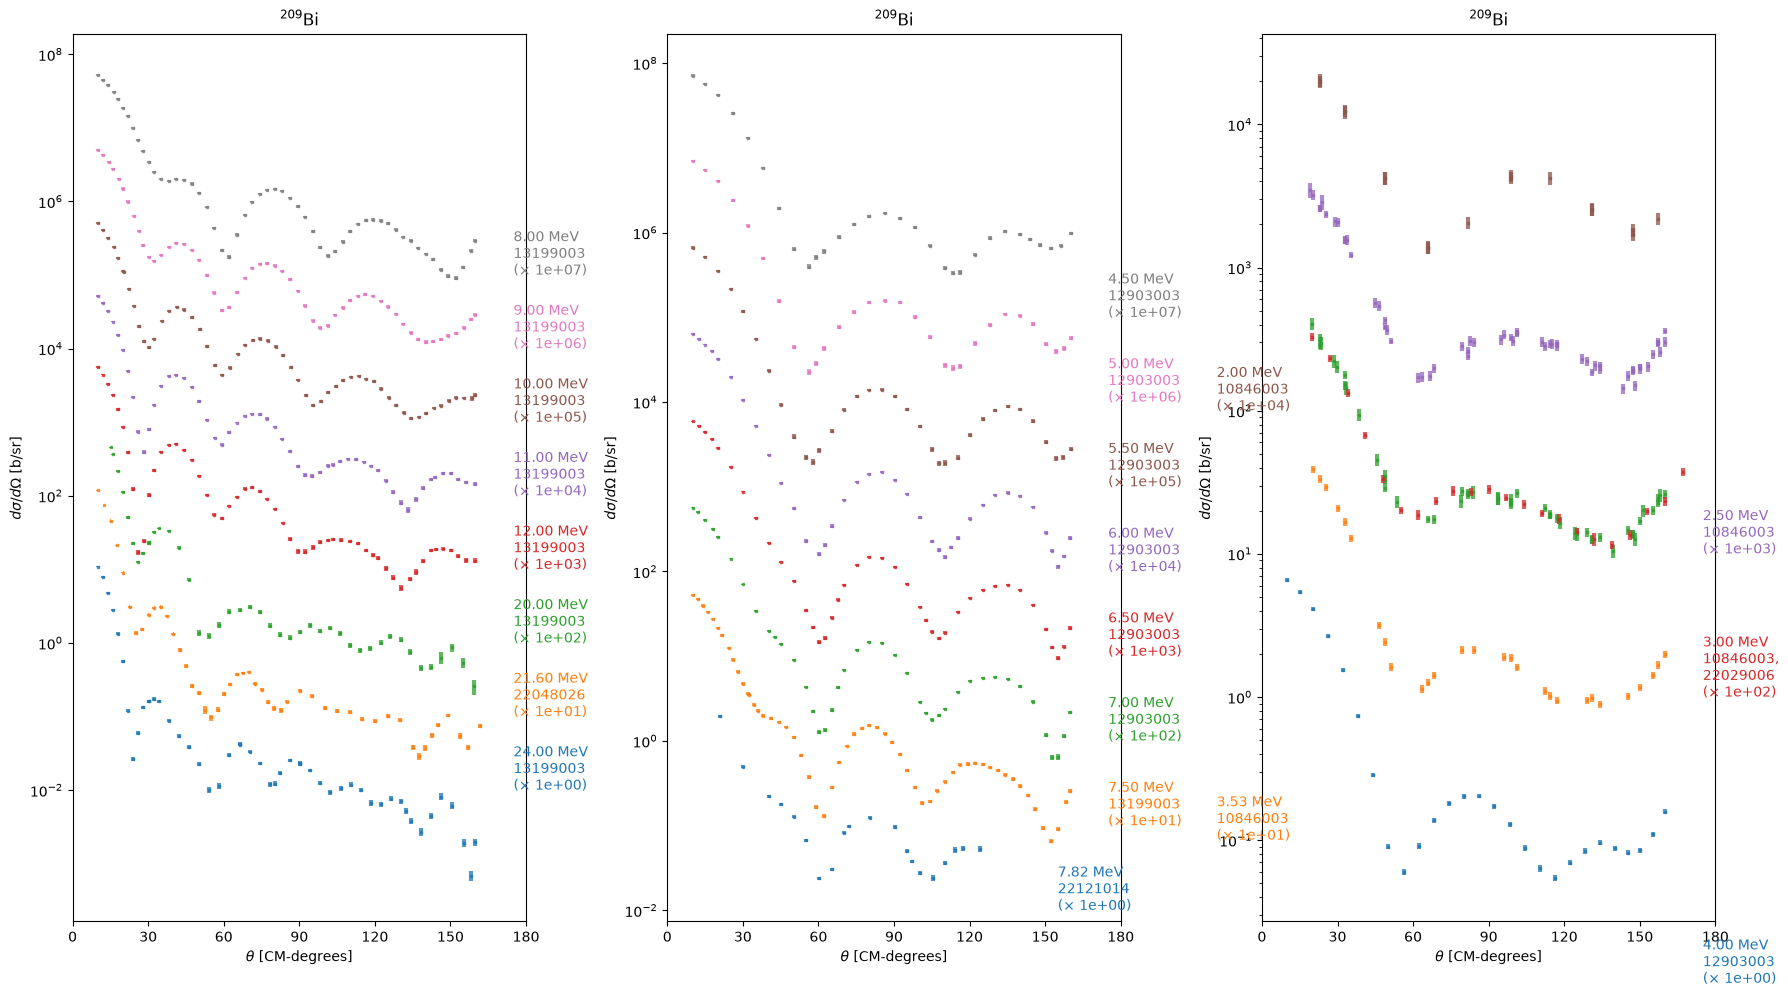

In [6]:
n_plotted = plotting.plot_sector(result)
assert n_plotted == len(result.records), (
    f"{len(result.records) - n_plotted} of {len(result.records)} data sets were not plotted")
print(f"plotted all {n_plotted} data sets")
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 579 measurements to data/kduq/neutron_elastic/
